<a href="https://colab.research.google.com/github/floresarthurjr/ecommerce-recommendation-engine/blob/main/notebooks/Arthur_C_Flores_Jr__Pillar_5_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Step 1: Problem Understanding & Framing**

*   Frame the business and data science problem clearly
*   Define whether it's a classification, regression, recommendation, anomaly detection, or clustering task
* Specify success metrics (e.g., Accuracy, AUC, RMSE, Silhouette Score) and business KPIs (e.g., cost savings, uplift)
* Capstone linkage: Module 1 output maps to Capstone Steps 1–3

**Deliverable:**
Clear problem statement + task type + target metric

# **BUSINESS PROBLEM:**
An eCommerce platform seeks to increase Average Order Value (AOV) and customer retention through personalized product recommendations.

Currently, products are shown generically to all users, missing cross-sell and upsell opportunities driven by individual customer preferences, demographics, and purchase history.

# **DATA SCIENCE PROBLEM:**
Given a user's interaction history and demographic profile, predict and rank the Top-K items they are most likely to purchase or engage with next.

This is a Recommendation System task using a hybrid approach of collaborative filtering + content-based filtering, with K-Means clustering for cold-start users and XGBoost as a supervised meta-learner for final ranking.

**TASK TYPE: Recommendation System (Hybrid)**


# **TECHNICAL SUCCESS METRICS:**
While capstone instructions specify success metrics such as Accuracy, AUC, RMSE, and Silhouette Score as examples, our use case produces a ranked list of product recommendations; and not a single label prediction.

We will instead extend Precision and Recall taught in our Module 4 (Regression and Classification Algorithms) to the more ranking-aware variants, which are standard metrics for recommendation system evaluation.

* Primary: Precision@K, Recall@K, NDCG@K (K=5 and K=10)
  * Precision@K extends classification Precision (Module 4) to ranked lists: "Of K recommended items, how many did the user buy?"
  * Recall@K will be used for "Of all the items the user actually purchased, how many appeared in the Top-K list?"
  * NDCG@K (Normalized Discounted Cumulative Gain) captures positional relevance: items ranked higher in the Top-K list receives more credit than those ranked lower
    * NDCG@10 is the designated primary tollgate metric for Phase C model selection since this is more relevant for eCommerce business revenue by:
      * Evaluating both the correctness of the recommendations and their ranked order because it applies a logarithmic penalty to relevant items buried lower in the list
      * Ensuring the model is tuned not just to find the right products, but to present them where the customer is most likely to click  

* RMSE will be included as a supporting metric since the dataset contains explicit star ratings (Review Rating: 2.5–5.0) as confirmed with the data we've downloaded
* Silhouette Score used to validate K-Means clustering quality (Model 2)

# **BUSINESS KPIs:**
* Projected AOV uplift (%) - will be estimated from the difference in average purchase amount between recommended vs. non-recommended product categories
* Click-through rate (CTR) on recommendations - will be simulated by measuring how often a user's actual purchase appears in their Top-K recommendation list (our proxy to assume "would the user have clicked")

# **Step 2: Data Collection & Understanding**

* Use public datasets (Kaggle, UCI, APIs, etc.) or approved custom data
* Summarise feature types, missing values, outliers, etc.
* Provide a **data dictionary** (variables, types, units, allowed values)

**Deliverable:**
Dataset overview + data dictionary

# **Use of public dataset - Kaggle**

In [1]:
!pip install kagglehub --upgrade -q
!pip install lime
import kagglehub
path = kagglehub.dataset_download("iamsouravbanerjee/customer-shopping-trends-dataset")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=7d930b099778428eed7bdc86aa7650649f1463449fad5a0dcd06ffbe3c7ddb7f
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


100%|██████████| 146k/146k [00:00<00:00, 30.5MB/s]

Extracting files...


In [2]:
import pandas as pd
import numpy as np
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import make_scorer
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from collections import defaultdict
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
import shap
from lime.lime_tabular import LimeTabularExplainer
from sklearn.inspection import PartialDependenceDisplay

In [3]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)

In [4]:
df = pd.read_csv(f"{path}/shopping_trends_updated.csv")
df

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Hoodie,Clothing,28,Virginia,L,Turquoise,Summer,4.2,No,2-Day Shipping,No,No,32,Venmo,Weekly
3896,3897,52,Female,Backpack,Accessories,49,Iowa,L,White,Spring,4.5,No,Store Pickup,No,No,41,Bank Transfer,Bi-Weekly
3897,3898,46,Female,Belt,Accessories,33,New Jersey,L,Green,Spring,2.9,No,Standard,No,No,24,Venmo,Quarterly
3898,3899,44,Female,Shoes,Footwear,77,Minnesota,S,Brown,Summer,3.8,No,Express,No,No,24,Venmo,Weekly


# **Dataset Overview**
## Summarise feature types, missing values, outliers, etc.


In [5]:
print(df.info())
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [6]:
print(f"\n--- Column Data Types ---")
print(df.dtypes)


--- Column Data Types ---
Customer ID                 int64
Age                         int64
Gender                     object
Item Purchased             object
Category                   object
Purchase Amount (USD)       int64
Location                   object
Size                       object
Color                      object
Season                     object
Review Rating             float64
Subscription Status        object
Shipping Type              object
Discount Applied           object
Promo Code Used            object
Previous Purchases          int64
Payment Method             object
Frequency of Purchases     object
dtype: object


In [7]:
print("\n--- Unique Values Per Column ---")
for col in df.columns:
    print(f"{col:40s}{df[col].nunique():>6} unique values")


--- Unique Values Per Column ---
Customer ID                               3900 unique values
Age                                         53 unique values
Gender                                       2 unique values
Item Purchased                              25 unique values
Category                                     4 unique values
Purchase Amount (USD)                       81 unique values
Location                                    50 unique values
Size                                         4 unique values
Color                                       25 unique values
Season                                       4 unique values
Review Rating                               26 unique values
Subscription Status                          2 unique values
Shipping Type                                6 unique values
Discount Applied                             2 unique values
Promo Code Used                              2 unique values
Previous Purchases                          50 uniq

### Outlier Detection

* We used the IQR (Interquartile Range) method to identify potential outliers in numerical columns
* Any treatment or handling of outliers will be addressed in Step 3 (Data Preprocessing & Feature Engineering), our main approach in this step is mainly for detection and observation

Outlier Detection (IQR Method):

  Age: Q1=31.0, Q3=57.0, IQR=26.0, Bounds=[-8.0, 96.0], Outliers: 0
  Purchase Amount (USD): Q1=39.0, Q3=81.0, IQR=42.0, Bounds=[-24.0, 144.0], Outliers: 0
  Review Rating: Q1=3.1, Q3=4.4, IQR=1.3000000000000003, Bounds=[1.1, 6.4], Outliers: 0
  Previous Purchases: Q1=13.0, Q3=38.0, IQR=25.0, Bounds=[-24.5, 75.5], Outliers: 0


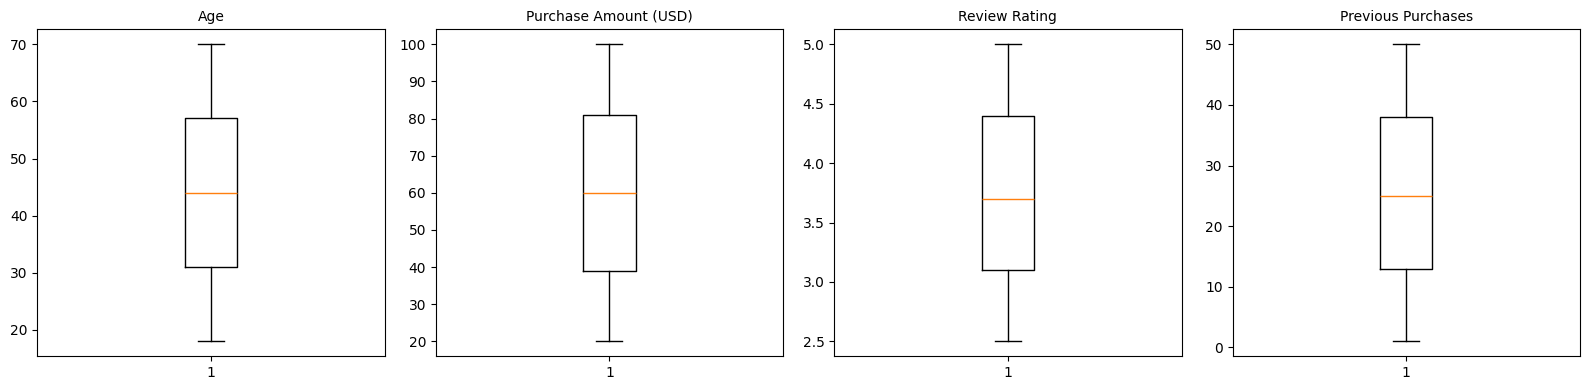

In [8]:
numerical_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

print("Outlier Detection (IQR Method):")
print()
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outlier_count = len(df[(df[col] < lower) | (df[col] > upper)])
    print(f"  {col}: Q1={Q1}, Q3={Q3}, IQR={IQR}, Bounds=[{lower:.1f}, {upper:.1f}], Outliers: {outlier_count}")

# Box plots for visual confirmation
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=10)

plt.tight_layout()
plt.savefig('phase_a_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* No outliers detected across all numerical columns using the IQR method
* This is might be due to the dataset being curated/synthetic as declared in Kaggle
* No outlier treatment is required in Step 3, but we will document this finding in the preprocessing section for completeness

# **Additional Data Validation**
## Oveview of Demographic Vectors in preparation for Bias Auditing (Step 5)

In [9]:
demographic_cols = []

In [10]:
# Age
if 'Age' in df.columns:
  print(f"Age Range: {df['Age'].min()} - {df['Age'].max()} with Mean of {df['Age'].mean():.1f}")
  demographic_cols.append('Age')
# Gender
if 'Gender' in df.columns:
    print(f"Gender Values: {df['Gender'].unique().tolist()} with Distribution of {df['Gender'].value_counts().to_dict()}")
    demographic_cols.append('Gender')
# Location
if 'Location' in df.columns:
    print(f"Unique Locations: {df['Location'].nunique()}")
    demographic_cols.append('Location')


Age Range: 18 - 70 with Mean of 44.1
Gender Values: ['Male', 'Female'] with Distribution of {'Male': 2652, 'Female': 1248}
Unique Locations: 50


In [11]:
# Create age groups for downstream use
bins = [0, 25, 35, 50, 100]
labels = ['18-25', '26-35', '36-50', '50+']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels, right=True)

# Check if demographic groups have enough users for reliable bias analysis
print(df['Gender'].value_counts().to_string())
print()
print(df['age_group'].value_counts().sort_index().to_string())

Gender
Male      2652
Female    1248

age_group
18-25     571
26-35     742
36-50    1111
50+      1476


In [12]:
# Product features available for Content-Based model (Model 4)
print("Product Features for Content-Based Modeling:")
product_feature_cols = ['Item Purchased', 'Category', 'Size', 'Color', 'Season']
for col_name in product_feature_cols:
  print(f"  {col_name}: {df[col_name].nunique()} unique {df[col_name].unique()[:5].tolist()}")

# Check if any column has long text to determine if we will enable TF-IDF
has_text = any(df[col].dtype == 'object' and df[col].str.len().mean() > 50 for col in df.columns)
print(f"Text descriptions available: {has_text}")

Product Features for Content-Based Modeling:
  Item Purchased: 25 unique ['Blouse', 'Sweater', 'Jeans', 'Sandals', 'Sneakers']
  Category: 4 unique ['Clothing', 'Footwear', 'Outerwear', 'Accessories']
  Size: 4 unique ['L', 'S', 'M', 'XL']
  Color: 25 unique ['Gray', 'Maroon', 'Turquoise', 'White', 'Charcoal']
  Season: 4 unique ['Winter', 'Spring', 'Summer', 'Fall']
Text descriptions available: False


**Observation:**
* No text descriptions found in the dataset
* Content-Based model (Model 4) will use multi-hot encoding on Category, Size, Color, and Season with cosine similarity
* Product features available: Item Purchased (25 unique), Category (4), Size (4), Color (25), Season (4) which has sufficient richness for content-based modeling

In [13]:
# Review Rating validation to determine if RMSE is applicable
if 'Review Rating' in df.columns:
    print("Explicit ratings found under column: Review Rating")
    print(f"  Range: {df['Review Rating'].min()} to {df['Review Rating'].max()}")
    print(f"  Mean: {df['Review Rating'].mean():.2f} with Std: {df['Review Rating'].std():.2f}")
    print(df['Review Rating'].describe())
    rmse_included = True
else:
    rmse_included = False

Explicit ratings found under column: Review Rating
  Range: 2.5 to 5.0
  Mean: 3.75 with Std: 0.72
count    3900.000000
mean        3.749949
std         0.716223
min         2.500000
25%         3.100000
50%         3.700000
75%         4.400000
max         5.000000
Name: Review Rating, dtype: float64


**Decision:**
* RMSE is included as a supporting metric since the dataset contains explicit star ratings (Review Rating: 2.5–5.0).
* This is consistent with our Technical Success Metrics definition in Step 1.

In [14]:
# Missing values
print("Missing Values:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("  No Missing Values")
else:
    print(missing[missing > 0])

# Duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Customer ID and interaction sparsity
unique_customers = df['Customer ID'].nunique()
unique_items = df['Item Purchased'].nunique()
total_possible = unique_customers * unique_items
sparsity = 1 - (len(df) / total_possible)

print(f"\nInteraction Matrix:")
print(f"  Unique customers: {unique_customers}")
print(f"  Unique items: {unique_items}")
print(f"  Transactions: {len(df)}")
print(f"  Possible interactions: {total_possible:,}")
print(f"  Sparsity: {sparsity*100:.1f}%")
print(f"  Avg transactions per customer: {len(df) / unique_customers:.1f}")

Missing Values:
  No Missing Values

Duplicate rows: 0

Interaction Matrix:
  Unique customers: 3900
  Unique items: 25
  Transactions: 3900
  Possible interactions: 97,500
  Sparsity: 96.0%
  Avg transactions per customer: 1.0


**Observations:**
* The dataset is clean with zero missing values and zero duplicate rows
* Each customer has exactly 1 transaction, resulting in a 96% sparse interaction matrix
  * This means, collaborative filtering (Model 3) will face a challenge
  * The reason to include K-Means (Model 2) and XGBoost (Model 5) in our model lineup, so we can handle this scenario

## Train/Test Split Strategy

* The dataset has no date or timestamp column, so a temporal split is not possible
* Instead, we will apply a demographic-stratified random split (80/20) stratified on age_group and Gender
* This preserves demographic distribution across both sets and ensures Step 5 bias auditing can be performed reliably on the test set
* This will be documented in the Step 5 Limitations section.

In [15]:
# Stratified 80/20 split on age_group and gender
df['_strat_key'] = df['Gender'] + '_' + df['age_group'].astype(str)

df_train, df_test = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df['_strat_key']
)

print(f"Training set: {len(df_train)} rows ({len(df_train)/len(df)*100:.0f}%)")
print(f"Test set: {len(df_test)} rows ({len(df_test)/len(df)*100:.0f}%)")

# Verify stratification
print("\nStratification Verification:")
for group in sorted(df['_strat_key'].unique()):
    train_pct = (df_train['_strat_key'] == group).mean() * 100
    test_pct = (df_test['_strat_key'] == group).mean() * 100
    print(f"  {group}: train {train_pct:.1f}%, test {test_pct:.1f}%")

# Clean up helper column
df_train = df_train.drop(columns=['_strat_key'])
df_test = df_test.drop(columns=['_strat_key'])
df = df.drop(columns=['_strat_key'])

Training set: 3120 rows (80%)
Test set: 780 rows (20%)

Stratification Verification:
  Female_18-25: train 4.4%, test 4.5%
  Female_26-35: train 6.2%, test 6.2%
  Female_36-50: train 9.6%, test 9.6%
  Female_50+: train 11.7%, test 11.8%
  Male_18-25: train 10.2%, test 10.1%
  Male_26-35: train 12.8%, test 12.8%
  Male_36-50: train 18.9%, test 18.8%
  Male_50+: train 26.1%, test 26.2%


**Result:**
* Demographic distribution is preserved across train and test sets
* All age_group and gender combinations show less than 1% variance between splits.

# **Data Dictionary**
## Provide a data dictionary (variables, types, units, allowed values).


| Column | Type | Unique | Missing | Description |
|--------|------|--------|---------|-------------|
| Customer ID | int64 | 3,900 | 0 | Unique identifier for each customer |
| Age | int64 | 53 | 0 | Customer age in years (demographic vector for Step 5 bias audit) |
| Gender | object | 2 | 0 | Customer gender which is Male, Female (demographic vector for Step 5 bias audit) |
| Item Purchased | object | 25 | 0 | Specific product name purchased by the customer |
| Category | object | 4 | 0 | Product category: Clothing, Accessories, Footwear, Outerwear |
| Purchase Amount (USD) | int64 | 81 | 0 | Transaction value in US dollars |
| Location | object | 50 | 0 | US state of the customer (demographic vector for Step 5 bias audit) |
| Size | object | 4 | 0 | Product size: S, M, L, XL |
| Color | object | 25 | 0 | Product color variant |
| Season | object | 4 | 0 | Season of purchase: Winter, Spring, Summer, Fall |
| Review Rating | float64 | 26 | 0 | Customer satisfaction score, 2.5 to 5.0 scale (explicit feedback) |
| Subscription Status | object | 2 | 0 | Whether the customer has an active subscription: Yes or No |
| Shipping Type | object | 6 | 0 | Shipping method selected |
| Discount Applied | object | 2 | 0 | Whether a discount was applied: Yes or No |
| Promo Code Used | object | 2 | 0 | Whether a promotional code was used: Yes or No |
| Previous Purchases | int64 | 50 | 0 | Count of prior purchases by this customer, range 1 to 50 |
| Payment Method | object | 6 | 0 | Payment method used for the transaction |
| Frequency of Purchases | object | 7 | 0 | Self-reported purchase frequency: Weekly, Bi-Weekly, etc. |
| age_group | category | 4 | 0 | Derived: Age segmented into 18-25, 26-35, 36-50, 50+ for bias auditing |

### Key Distributions

These visualizations serve a dual purpose:
* Provide an initial understanding of the dataset's structure and spread for Step 2
* Designed to be reusable in Step 6 presentations (technical and business decks) to avoid recreating charts later, adhering to the "Reusability" and DRY (Don't Repeat Yourself) principles across this project from standard Software Engineering and MLOps approach so our visuals are produced once and referenced across deliverables.

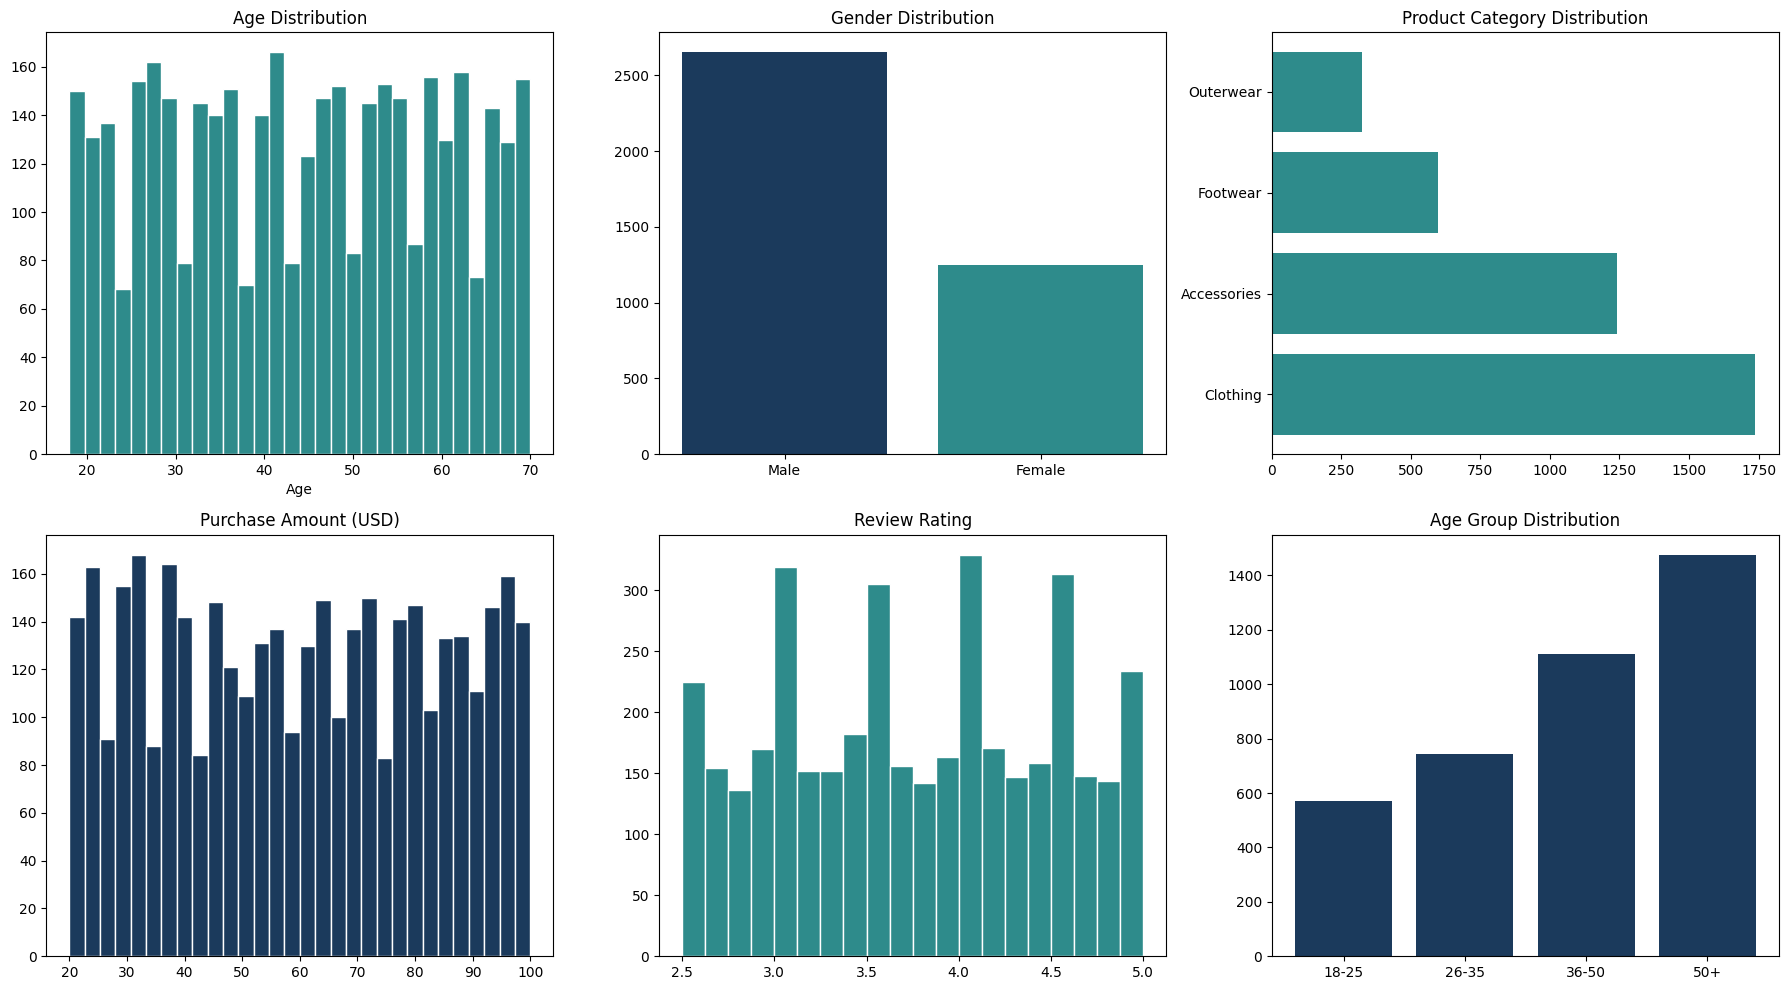

In [16]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
COLOR_PRIMARY = '#1B3A5C'
COLOR_SECONDARY = '#2E8B8B'
COLOR_ACCENT = '#D4820C'

# Age
axes[0, 0].hist(df['Age'], bins=30, color= COLOR_SECONDARY, edgecolor='white')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')

# Gender
gender_counts = df['Gender'].value_counts()
axes[0, 1].bar(gender_counts.index, gender_counts.values, color=[COLOR_PRIMARY, COLOR_SECONDARY])
axes[0, 1].set_title('Gender Distribution')

# Category
cat_counts = df['Category'].value_counts()
axes[0, 2].barh(cat_counts.index, cat_counts.values, color=COLOR_SECONDARY)
axes[0, 2].set_title('Product Category Distribution')

# Purchase Amount
axes[1, 0].hist(df['Purchase Amount (USD)'], bins=30, color=COLOR_PRIMARY, edgecolor='white')
axes[1, 0].set_title('Purchase Amount (USD)')

# Review Rating
axes[1, 1].hist(df['Review Rating'], bins=20, color=COLOR_SECONDARY, edgecolor='white')
axes[1, 1].set_title('Review Rating')

# Age Groups
age_counts = df['age_group'].value_counts().sort_index()
axes[1, 2].bar(age_counts.index.astype(str), age_counts.values, color=COLOR_PRIMARY)
axes[1, 2].set_title('Age Group Distribution')

plt.tight_layout()
plt.savefig('phase_a_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
df_train.to_csv('train_set.csv', index=False)
df_test.to_csv('test_set.csv', index=False)
df.to_csv('full_dataset_with_age_group.csv', index=False)

#**Phase A Summary: Foundation & Provisioning Delivered**

**Step 1: Problem Understanding & Framing:**
* **Business problem framed:** Increase AOV and retention through personalized product recommendations
* **Data science problem framed:** Predict and rank Top-K items users are likely to purchase or engage using a hybrid recommendation approach
* **Task type:** Recommendation System (Hybrid)
* **Technical metrics defined:**
  * Precision@K, Recall@K, NDCG@K (K=5, K=10) with NDCG@10 as primary tollgate metric
  * RMSE included as supporting metric (explicit ratings were confirmed)
  * Silhouette Score for K-Means cluster validation
* **Business KPIs:** Projected AOV uplift (%), CTR on recommendations

**Step 2 Data Collection & Understanding:**
* **Dataset:** Customer Shopping Trends Dataset (Kaggle, 3,900 rows × 18 columns)
* **Feature types:** 4 numerical (int64), 1 continuous (float64), 13 categorical (object), and 1 derived column (age_group)
* **Data quality:** Zero missing values, zero duplicates, zero outliers via IQR
* **Additional Data Validation Performed in preparation with succeeding steps:**
  * **Demographics validated:** Age (4 groups, all are more than 500 in count), Gender (2 groups, both are over 1,200), Location (50 US states)
  * **Product features:** 4 categorical features (Category, Size, Color, Season) will be used for multi-hot encoding in the content-based model, with Item Purchased serving as the item identifier
  * **Interaction type:** Explicit ratings (Review Rating 2.5 to 5.0)
  * Sparsity: 96% (1 transaction per customer), confirms K-Means and XGBoost architectural decision
* **Data dictionary** completed with types, unique values, and business meaning per column

**Solution Decisions Confirmed:**
* RMSE is included
* Content-based strategy: Multi-hot encoding on Category, Size, Color, Season
* Train/test split: 80/20 demographic-stratified random split because no temporal column is available. To be disclosed in Step 5 Limitations
* Primary tollgate metric: NDCG@10

**Next Phase: Phase B**
* **Step 3**: Data Preprocessing, Applied EDA & Feature Engineering

# **Step 3: Data Preprocessing, Applied EDA & Feature Engineering**

* Clean data: Handle nulls, duplicates and outliers
* Engineer features: Scaling, encoding, binning and domain-derived features
* Applied EDA: Distributions, relationships, clustering tendency (if unsupervised)
* Feature importance & explainability: SHAP, LIME, or model-based importances
* Feature selection: At least one approach (filter, wrapper, or embedded)
* Dimensionality reduction: PCA (and t-SNE/UMAP for visualisation if needed)

**Deliverable:**
"EDA + Feature Engineering Report" with reproducible code & justifications


# **Data Preprocessing**
## Clean data: Handle nulls, duplicates and outliers
* Phase A confirmed zero missing values, zero duplicate rows, and zero outliers (via IQR method) across all numerical columns
* No imputation or removal is required as documented in the Phase A cells above under Dataset Overview

## Engineer features: Scaling, encoding, binning and domain-derived features

**Binning:**
* Age was binned into four demographic groups (18-25, 26-35, 36-50, 50+) during Phase A (which can both be observed under "Additional Data Validation") for use in bias auditing and as a modeling feature
* This can also be additionally observed in the visuals created "Key Distributions"

In [18]:
df_encoded = df.copy()

# Binary encoding (0/1)
df_encoded['Gender'] = df_encoded['Gender'].map({'Male': 1, 'Female': 0})
df_encoded['Subscription Status'] = df_encoded['Subscription Status'].map({'Yes': 1, 'No': 0})
df_encoded['Discount Applied'] = df_encoded['Discount Applied'].map({'Yes': 1, 'No': 0})
df_encoded['Promo Code Used'] = df_encoded['Promo Code Used'].map({'Yes': 1, 'No': 0})

# Ordinal encoding (natural order)
size_order = {'S': 0, 'M': 1, 'L': 2, 'XL': 3}
df_encoded['Size'] = df_encoded['Size'].map(size_order)

freq_order = {
    'Annually': 0, 'Quarterly': 1, 'Every 3 Months': 2,
    'Monthly': 3, 'Bi-Weekly': 4, 'Fortnightly': 5, 'Weekly': 6
}
df_encoded['Frequency of Purchases'] = df_encoded['Frequency of Purchases'].map(freq_order)

# One-Hot encoding (no natural order)
nominal_cols = ['Category', 'Color', 'Season', 'Payment Method', 'Shipping Type']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=False)

print(f"Shape after encoding: {df_encoded.shape}")
print(f"Columns: {df_encoded.shape[1]}")
df_encoded

Shape after encoding: (3900, 59)
Columns: 59


,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases,age_group,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup
0,1,55,1,Blouse,53,Kentucky,2,3.1,1,1,1,14,5,50+,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False
1,2,19,1,Sweater,64,Maine,2,3.1,1,1,1,2,5,18-25,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False
2,3,50,1,Jeans,73,Massachusetts,0,3.1,1,1,1,23,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,4,21,1,Sandals,90,Rhode Island,1,3.5,1,1,1,49,6,18-25,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
4,5,45,1,Blouse,49,Oregon,1,2.7,1,1,1,31,0,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,0,Hoodie,28,Virginia,2,4.2,0,0,0,32,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False
3896,3897,52,0,Backpack,49,Iowa,2,4.5,0,0,0,41,4,50+,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True
3897,3898,46,0,Belt,33,New Jersey,2,2.9,0,0,0,24,1,36-50,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3898,3899,44,0,Shoes,77,Minnesota,0,3.8,0,0,0,24,6,36-50,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,Fals

**Encoding**
* Our model lineup will include distance-based (K-Means), tree-based (XGBoost), collaborative filtering, and content-based approaches
* Each consumes different input formats, so we prepared a unified encoded dataset that any downstream model can select from:

  * **Binary columns** (Gender, Subscription Status, Discount Applied, Promo Code Used): Mapped to 0 and 1
  * **Ordinal columns** (Size, Frequency of Purchases): Encoded with natural ordering preserved (e.g., S=0, M=1, L=2, XL=3)
  * **Nominal columns** (Category, Color, Season, Payment Method, Shipping Type): One-Hot Encoded since these have no natural order
  * **Item Purchased** was Left as-is since this is the item identifier used in the interaction matrix; and not a model feature
- **Customer ID** was also be left as-is since it will be our row identifier

In [19]:
# Scaling numerical features
# XGBoost tolerates unscaled but was included for consistency as it is required for K-Means since it is distance-based
numerical_cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print(df_encoded[numerical_cols].describe().round(2))
df_encoded


           Age  Purchase Amount (USD)  Review Rating  Previous Purchases
count  3900.00                3900.00        3900.00             3900.00
mean     -0.00                  -0.00           0.00                0.00
std       1.00                   1.00           1.00                1.00
min      -1.71                  -1.68          -1.75               -1.69
25%      -0.86                  -0.88          -0.91               -0.86
50%      -0.00                   0.01          -0.07               -0.02
75%       0.85                   0.90           0.91                0.88
max       1.71                   1.70           1.75                1.71


,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Review Rating,Subscription Status,Discount Applied,Promo Code Used,Previous Purchases,Frequency of Purchases,age_group,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup
0,1,0.718913,1,Blouse,-0.285629,Kentucky,2,-0.907584,1,1,1,-0.785831,5,50+,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False
1,2,-1.648629,1,Sweater,0.178852,Maine,2,-0.907584,1,1,1,-1.616552,5,18-25,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False
2,3,0.390088,1,Jeans,0.558882,Massachusetts,0,-0.907584,1,1,1,-0.162789,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,4,-1.517099,1,Sandals,1.276716,Rhode Island,1,-0.349027,1,1,1,1.637107,6,18-25,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False
4,5,0.061263,1,Blouse,-0.454531,Oregon,1,-1.466141,1,1,1,0.391025,0,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,-0.267563,0,Hoodie,-1.341267,Virginia,2,0.628448,0,0,0,0.460252,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,True,False,False,False,False,False
3896,3897,0.521618,0,Backpack,-0.454531,Iowa,2,1.047366,0,0,0,1.083293,4,50+,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,True
3897,3898,0.127028,0,Belt,-1.130139,New Jersey,2,-1.186862,0,0,0,-0.093563,1,36-50,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,True,False
3898,3899,-0.004502,0,Shoes,0.727784,Minnesota,0,0.069891,0,0,0,-0.093563,6,3

**Observation:**

* After encoding and scaling, the dataset expanded from 18 to 59 columns due to One-Hot encoding of nominal categories (Category, Color, Season, Payment Method, Shipping Type)
* Numerical features are now standardized with mean = 0 and std = 1, which is required for distance-based algorithms like K-Means
* Tree-based models such as XGBoost are not really affected by scaling but a consistent representation simplifies our pipeline

## Applied EDA: Distributions, relationships, clustering tendency (if unsupervised)

* Basic Distribustion can be observed under "Key Distributions" section of the code, showing distributions of age, gender, category, purchase amount, and review rating
* So in this section, we will focus more on relationship and patterns that will feed into our Business Insight, recommendation logic, and bias auditing

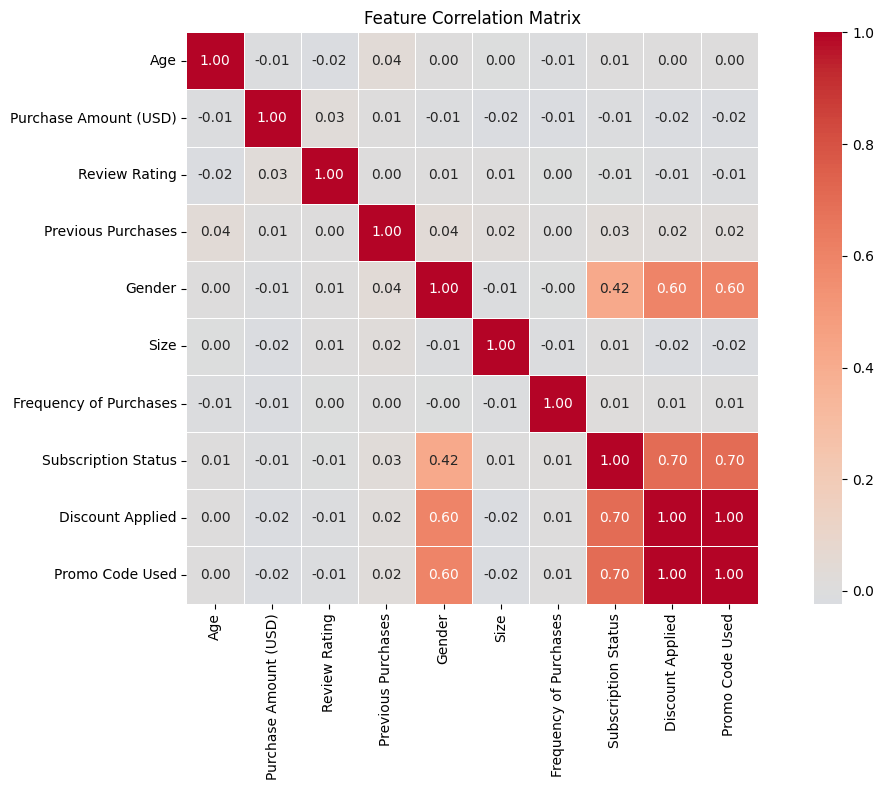

In [20]:
# Correlation heatmap on numerical features
numerical_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
                      'Gender', 'Size', 'Frequency of Purchases', 'Subscription Status',
                      'Discount Applied', 'Promo Code Used']

corr_matrix = df_encoded[numerical_features].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('phase_b_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations from Correlation Analysis:**
* **Discount Applied and Promo Code Used have a perfect correlation of 1.00**: these means that the two columns contain identical information
  * We will drop "Promo Code Used" before modeling since it is identical to "Discount Applied" to avoid redundancy
* **Subscription Status correlates with Discount Applied (0.70) or Promo Code Used (0.70)**: this suggest subscribers are more likely to use discounts and promos
* **Gender shows moderate correlation with Subscription Status (0.42) and Discount Applied (0.60)**: this imply that both these features are not independent of gender
  * The nature of this relationship will be explored further during Step 5 bias auditing
* **Age, Purchase Amount, Review Rating, and Previous Purchases show near-zero correlations with each other**: this means that these features are largely independent from each other
  * This is good for our modeling since they each carry unique information without multicollinearity


In [21]:
df_encoded = df_encoded.drop(columns=['Promo Code Used'])
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 58 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Customer ID                   3900 non-null   int64   
 1   Age                           3900 non-null   float64 
 2   Gender                        3900 non-null   int64   
 3   Item Purchased                3900 non-null   object  
 4   Purchase Amount (USD)         3900 non-null   float64 
 5   Location                      3900 non-null   object  
 6   Size                          3900 non-null   int64   
 7   Review Rating                 3900 non-null   float64 
 8   Subscription Status           3900 non-null   int64   
 9   Discount Applied              3900 non-null   int64   
 10  Previous Purchases            3900 non-null   float64 
 11  Frequency of Purchases        3900 non-null   int64   
 12  age_group                     3900 non-null   ca

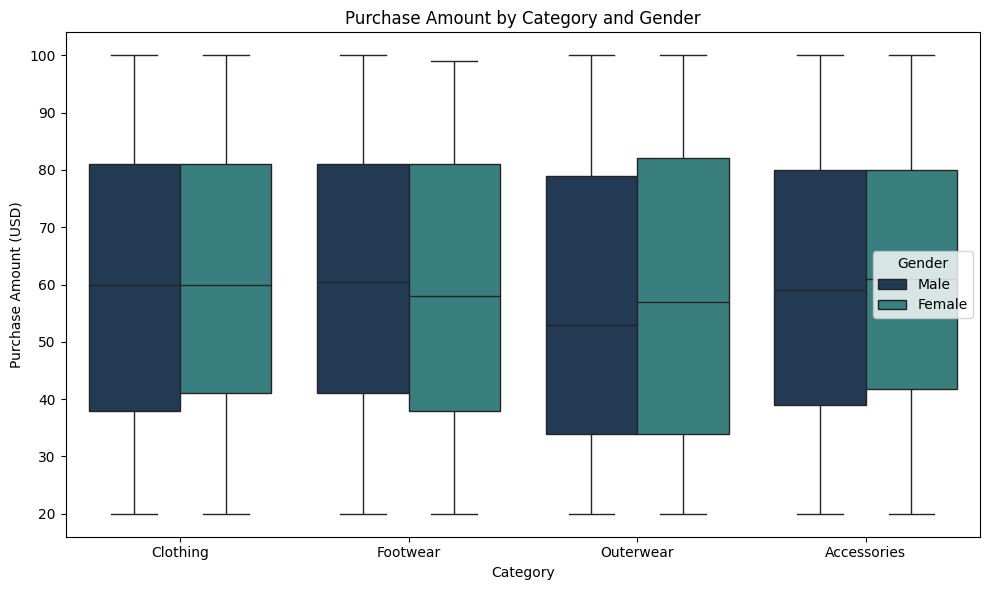

In [22]:
# Purchase amount by category and gender (used original df for more readable labels)
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='Purchase Amount (USD)', hue='Gender',
            palette=[COLOR_PRIMARY, COLOR_SECONDARY])
ax.set_title('Purchase Amount by Category and Gender')
plt.tight_layout()
plt.savefig('phase_b_category_gender_spending.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Purchase amounts are distributed similarly across all four categories and both genders
* Medians hover around $55 to $60 with comparable spread
* This suggests that purchase amount alone is not a strong differentiator for recommending products
* The recommendation engine should rely more on other features like category preferences and item-level behavior than on spending patterns

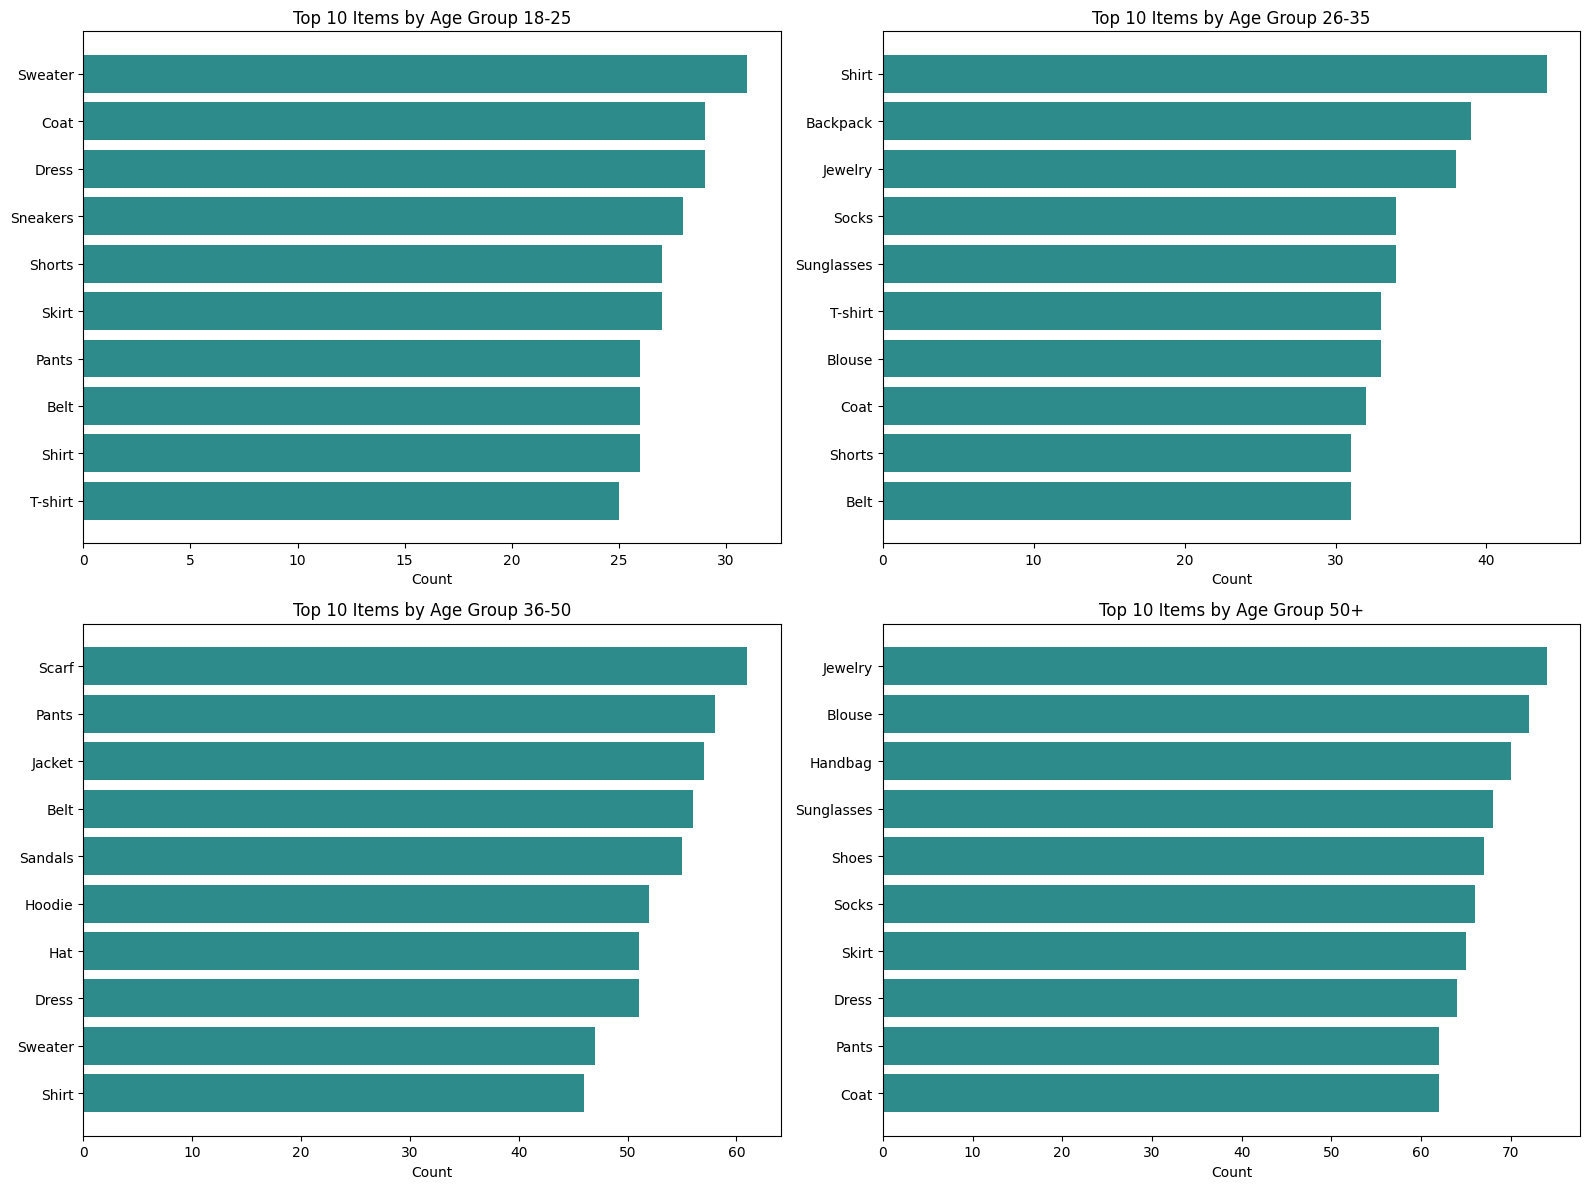

In [23]:
# Top 10 most purchased items per age group
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
age_groups = ['18-25', '26-35', '36-50', '50+']

for i, ag in enumerate(age_groups):
    ax = axes[i // 2][i % 2]
    subset = df[df['age_group'] == ag]
    item_counts = subset['Item Purchased'].value_counts().head(10)
    ax.barh(item_counts.index, item_counts.values, color=COLOR_SECONDARY)
    ax.set_title(f'Top 10 Items by Age Group {ag}')
    ax.set_xlabel('Count')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('phase_b_item_popularity_by_age.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**

Item preferences show some variation across age groups, though the counts are relatively evenly distributed within each group (might be due to the data being synthetic)
* **18-25:** Sweater, Coat, and Dress lead which skews toward smart casual and seasonal clothing
* **26-35:** Shirt, Backpack, and Jewelry top the list which is a mix of professional and accessory items
* **36-50:** Scarf, Pants, and Jacket dominate which are more practical, work-appropriate items
* **50+:** Jewelry, Blouse, and Handbag lead which are accessories and classic clothing items
  * The 50+ group shows the highest item counts overall, which is expected since it has the largest population (1,476 users)
* These age-specific preferences support using age group as a feature in the recommendation model, particularly for the K-Means cluster-based approach where cluster-level item popularity drives recommendations

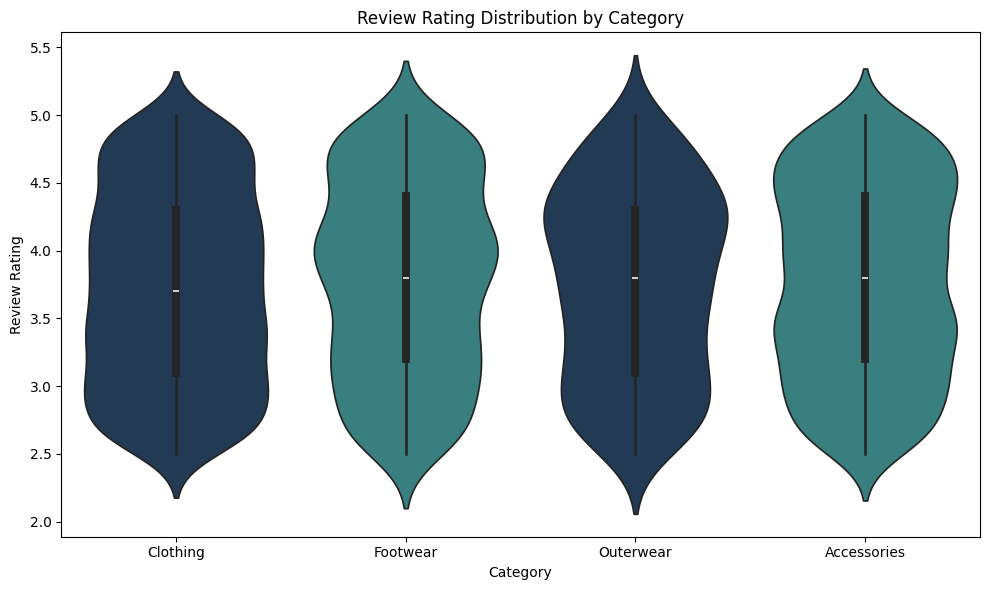

Category
Accessories    3.8
Clothing       3.7
Footwear       3.8
Outerwear      3.8
Name: Review Rating, dtype: float64


In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(data=df, x='Category', y='Review Rating',
               palette=[COLOR_PRIMARY, COLOR_SECONDARY, COLOR_PRIMARY, COLOR_SECONDARY])
ax.set_title('Review Rating Distribution by Category')
plt.tight_layout()
plt.savefig('phase_b_rating_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print(df.groupby('Category')['Review Rating'].median())

**Observation:**

Review rating distributions are nearly identical across all four categories, with medians around 3.7 to 3.8 and similar spread
* All categories show a roughly uniform distribution between 2.5 and 5.0, with no category standing out as significantly better or worse rated
* This means review rating alone will not be a useful feature for differentiating between categories in the recommendation model since it carries customer satisfaction signal but not category preference signal
* This further support our correlation heatmap where Review Rating showed near-zero correlation with other features

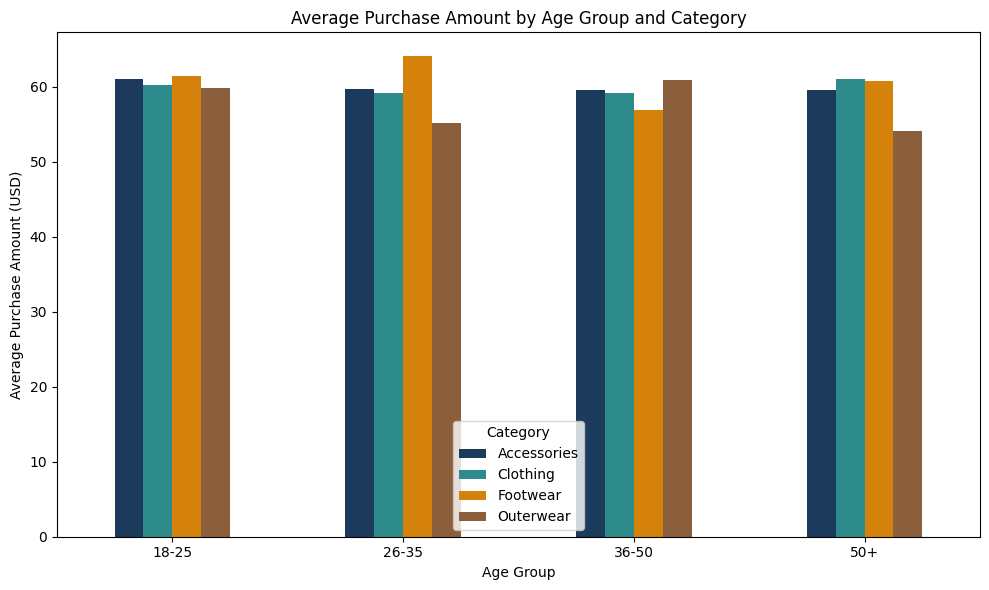


Average Purchase Amount by Age Group vs Category:
Category   Accessories  Clothing  Footwear  Outerwear
age_group                                            
18-25            61.11     60.30     61.38      59.78
26-35            59.67     59.18     64.06      55.22
36-50            59.62     59.13     56.86      60.92
50+              59.63     61.01     60.74      54.08


In [25]:
# Average purchase amount by age group and category
spending = df.groupby(['age_group', 'Category'])['Purchase Amount (USD)'].mean().unstack()

fig, ax = plt.subplots(figsize=(10, 6))
spending.plot(kind='bar', ax=ax, color=[COLOR_PRIMARY, COLOR_SECONDARY, '#D4820C', '#8B5E3C'])
ax.set_title('Average Purchase Amount by Age Group and Category')
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Purchase Amount (USD)')
ax.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('phase_b_spending_age_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAverage Purchase Amount by Age Group vs Category:")
print(spending.round(2))

**Observation:**
* Average spending is consistent across all age group and category combinations (within the $55 to $64 range)
* Slight variations observed:
  * 26-35 group spends slightly higher on Footwear ($64.06) while less on Outerwear ($55.22)
  * Similar Outerwear spending pattern ($54.08) observed with 50+ group
* Overall, spending amount does not vary meaningfully by age group or category which reinforces earlier finding from chart 2 that purchase amount is not a strong differentiator
* The recommendation engine's value will come from predicting *which* items a user wants, not *how much* they spend
  * Item preference patterns as observed in chart 3 (Top 10 most purchased items per age group graph) are more actionable than spending patterns

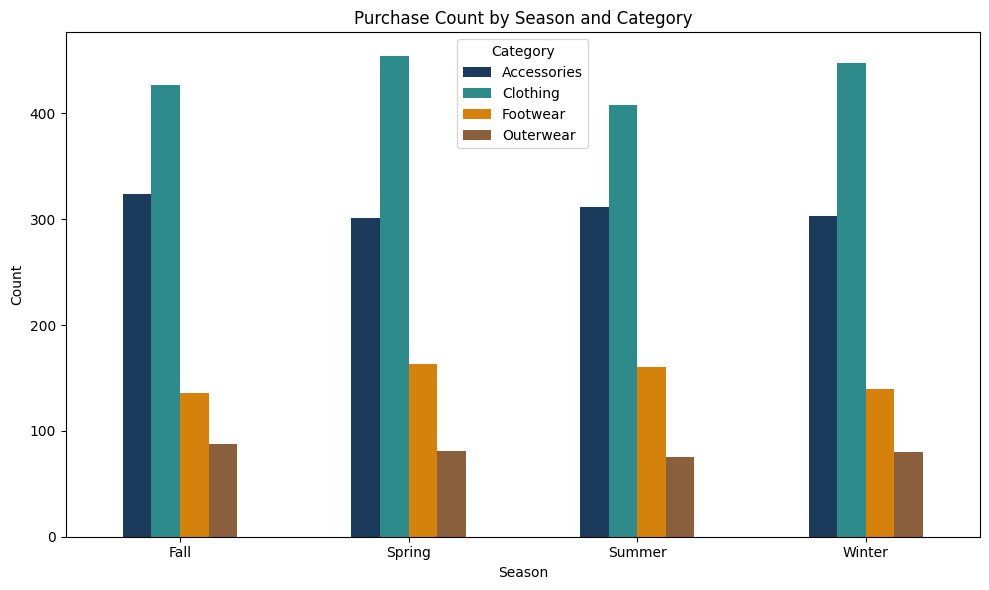

Category,Accessories,Clothing,Footwear,Outerwear
Season,,,,
Fall,324,427,136,88
Spring,301,454,163,81
Summer,312,408,160,75
Winter,303,448,140,80


In [26]:
# Season vs Category cross-tabulation
season_cat = pd.crosstab(df['Season'], df['Category'])
fig, ax = plt.subplots(figsize=(10, 6))
season_cat.plot(kind='bar', ax=ax, color=[COLOR_PRIMARY, COLOR_SECONDARY, '#D4820C', '#8B5E3C'])
ax.set_title('Purchase Count by Season and Category')
ax.set_xlabel('Season')
ax.set_ylabel('Count')
ax.legend(title='Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('phase_b_season_category.png', dpi=150, bbox_inches='tight')
plt.show()

season_cat = pd.crosstab(df['Season'], df['Category'])
season_cat

**Observation:**
* Clothing dominates all four seasons (408-454 purchases), followed by Accessories (301-324), Footwear (136-163), and Outerwear (75-88)
* The distribution is relatively consistent across seasons with no strong seasonal shifts (e.g., Outerwear does not spike significantly in Winter as what might be typically expected)
* While the seasonal variation is subtle, the season vs category interaction may still capture minor patterns that individual columns alone would miss, so we will engineer this as a combined feature in the next our Domain-Driven Feature Engineering to be sure

### Domain-Driven Feature Engineering

* Originally anticipated features like purchase_frequency, days_since_last_purchase, average_order_value, category_diversity_score, and brand_loyalty_index

  * However, the dataset chosen contains 1 transaction per customer only with no date column and no brand column
  * This limited some of the planned features but opened an opportunity to engineer different ones that leverage the data we have

* The main goal is to create features that helps the recommendation models understand user preferences and behavior beyond the raw columns
* Applied EDA was performed before feature engineering so the patterns discovered in the data could directly inform which features to create

**Feature rationale and origin:**

* **spending_tier (EDA-driven):** Charts 2 and 5 showed raw purchase amount doesn't differentiate well across segments
  * Binning this into tiers, however, may reveal broader spending patterns the continuous may have missed
- **engagement_score (Domain-driven):** From my experience in eCommerce with online retail, engagement scoring is standard CRM practice
  * Combining purchase history, subscription, and discount usage into a single behavioral metric generally shows relevant results
* **season_category (EDA-driven):** Chart 6 (Season vs Category) showed subtle seasonal patterns
  * Capturing this interaction lets the model decide if the combined signal adds value beyond individual columns
* **customer_maturity (Domain-driven):** Since no date column exists, Previous Purchases serves as a proxy for customer lifecycle stage
  * Segmenting customers into new/regular/loyal is a common eCommerce practice for tailoring recommendations differently based on relationship maturity

In [27]:
# Domain-driven feature engineering
# Worked on the original df (not df_encoded) since we need readable labels for feature logic
# New features will be encoded and added to df_encoded

# Spending Tier: Bin customers into spending segments
# Business logic: high spenders may prefer premium items
df['spending_tier'] = pd.qcut(df['Purchase Amount (USD)'], q=3, labels=['low', 'mid', 'high'])
print(df['spending_tier'].value_counts().sort_index())

# Engagement Score: Combines purchase history with subscription and discount usage
# Business logic: higher engagement may mean more data for the model to learn from
df['engagement_score'] = (
    df['Previous Purchases'] +
    (df['Subscription Status'] == 'Yes').astype(int) +
    (df['Discount Applied'] == 'Yes').astype(int)
)
print("\nengagement_score:")
print(df['engagement_score'].describe().round(2))

# Season-Category Preference: Concatenation to capture seasonal shopping patterns
# Business logic: some customers buy outerwear in winter, accessories in summer
df['season_category'] = df['Season'] + '_' + df['Category']
print("\nSeason-Category Preference:")
print(df['season_category'].value_counts().head(8))

# Customer Maturity: Proxy for customer lifecycle using Previous Purchases since we don't have a date column
# Business logic: customers with more history have more established preferences (e.g. new vs regular vs loyal customers may need different recommendation)
df['customer_maturity'] = pd.qcut(df['Previous Purchases'], q=3, labels=['new', 'regular', 'loyal'])
print("\nPrevious Purchases:")
print(df['customer_maturity'].value_counts().sort_index())

print(f"\nTotal features after engineering: {df.shape[1]} columns")

spending_tier
low     1300
mid     1303
high    1297
Name: count, dtype: int64

engagement_score:
count    3900.00
mean       26.05
std        14.50
min         1.00
25%        14.00
50%        26.00
75%        39.00
max        52.00
Name: engagement_score, dtype: float64

Season-Category Preference:
season_category
Spring_Clothing       454
Winter_Clothing       448
Fall_Clothing         427
Summer_Clothing       408
Fall_Accessories      324
Summer_Accessories    312
Winter_Accessories    303
Spring_Accessories    301
Name: count, dtype: int64

Previous Purchases:
customer_maturity
new        1316
regular    1295
loyal      1289
Name: count, dtype: int64

Total features after engineering: 23 columns


**Observation:**
* All four features created successfully, expanding the dataset from 18 to 24 columns
* spending_tier and customer_maturity both produced balanced groups (~1,300 each) using data-driven tercile splits (pd.qcut), ensuring equal representation for modeling
* engagement_score ranges from 1 to 52 with good variance (std=14.50), giving the model meaningful signal to differentiate customer behavior levels
* season_category produced 16 combinations (4 seasons by 4 categories)
  * This is consistent with our EDA chart 6 findings where Clothing dominated across all seasons

In [28]:
# Add new features to df_encoded
df_encoded['spending_tier'] = df['spending_tier'].map({'low': 0, 'mid': 1, 'high': 2})
df_encoded['engagement_score'] = df['engagement_score']
df_encoded['season_category'] = df['season_category']
df_encoded['customer_maturity'] = df['customer_maturity'].map({'new': 0, 'regular': 1, 'loyal': 2})

# Scale engineered numerical features to match previously scaled columns
new_numerical = ['engagement_score', 'spending_tier', 'customer_maturity']
scaler_new = StandardScaler()
df_encoded[new_numerical] = scaler_new.fit_transform(df_encoded[new_numerical])

# One-hot encode season_category
df_encoded = pd.get_dummies(df_encoded, columns=['season_category'], drop_first=False)

df_encoded

,Customer ID,Age,Gender,Item Purchased,Purchase Amount (USD),Location,Size,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Frequency of Purchases,age_group,Category_Accessories,Category_Clothing,Category_Footwear,Category_Outerwear,Color_Beige,Color_Black,Color_Blue,Color_Brown,Color_Charcoal,Color_Cyan,Color_Gold,Color_Gray,Color_Green,Color_Indigo,Color_Lavender,Color_Magenta,Color_Maroon,Color_Olive,Color_Orange,Color_Peach,Color_Pink,Color_Purple,Color_Red,Color_Silver,Color_Teal,Color_Turquoise,Color_Violet,Color_White,Color_Yellow,Season_Fall,Season_Spring,Season_Summer,Season_Winter,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo,Shipping Type_2-Day Shipping,Shipping Type_Express,Shipping Type_Free Shipping,Shipping Type_Next Day Air,Shipping Type_Standard,Shipping Type_Store Pickup,spending_tier,engagement_score,customer_maturity,season_category_Fall_Accessories,season_category_Fall_Clothing,season_category_Fall_Footwear,season_category_Fall_Outerwear,season_category_Spring_Accessories,season_category_Spring_Clothing,season_category_Spring_Footwear,season_category_Spring_Outerwear,season_category_Summer_Accessories,season_category_Summer_Clothing,season_category_Summer_Footwear,season_category_Summer_Outerwear,season_category_Winter_Accessories,season_category_Winter_Clothing,season_category_Winter_Footwear,season_category_Winter_Outerwear
0,1,0.718913,1,Blouse,-0.285629,Kentucky,2,-0.907584,1,1,-0.785831,5,50+,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,0.000943,-0.693377,-1.215142,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,2,-1.648629,1,Sweater,0.178852,Maine,2,-0.907584,1,1,-1.616552,5,18-25,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,0.000943,-1.521163,-1.215142,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
2,3,0.390088,1,Jeans,0.558882,Massachusetts,0,-0.907584,1,1,-0.162789,6,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,0.000943,-0.072537,0.008471,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
3,4,-1.517099,1,Sandals,1.276716,Rhode Island,1,-0.349027,1,1,1.637107,6,18-25,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,1.226395,1.721000,1.232084,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
4,5,0.061263,1,Blouse,-0.454531,Oregon,1,-1.466141,1,1,0.391025,0,36-50,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,0.000943,0.479320,0.008471,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,

### Feature selection: At least one approach (filter, wrapper, or embedded)

We apply a dual-method approach:
* **Filter method (already completed):** Correlation analysis was done under "Applied EDA: Distributions, relationships, clustering tendency (if unsupervised)" which led to actionable decisions:
  * Promo Code Used was dropped due to perfect correlation (1.00) with Discount Applied
  * Gender's moderate correlation with Subscription Status (0.42) and Discount Applied (0.60) was flagged for Step 5 bias auditing
  * Near-zero correlations among Age, Purchase Amount, Review Rating, and Previous Purchases confirmed they carry independent information without multicollinearity

* **Embedded method:** XGBoost feature importance trained to predict product Category
  * This directly answers which customer features drive product preference, which is a core question for our recommendation engine


Top 15 Features by XGBoost Importance:
Discount Applied          0.0827
Frequency of Purchases    0.0768
Shipping Type             0.0757
Payment Method            0.0753
Size                      0.0743
Review Rating             0.0713
Subscription Status       0.0706
Color                     0.0696
Age                       0.0690
Gender                    0.0679
Purchase Amount (USD)     0.0673
Previous Purchases        0.0668
engagement_score          0.0665
Season                    0.0660
Promo Code Used           0.0000
dtype: float32


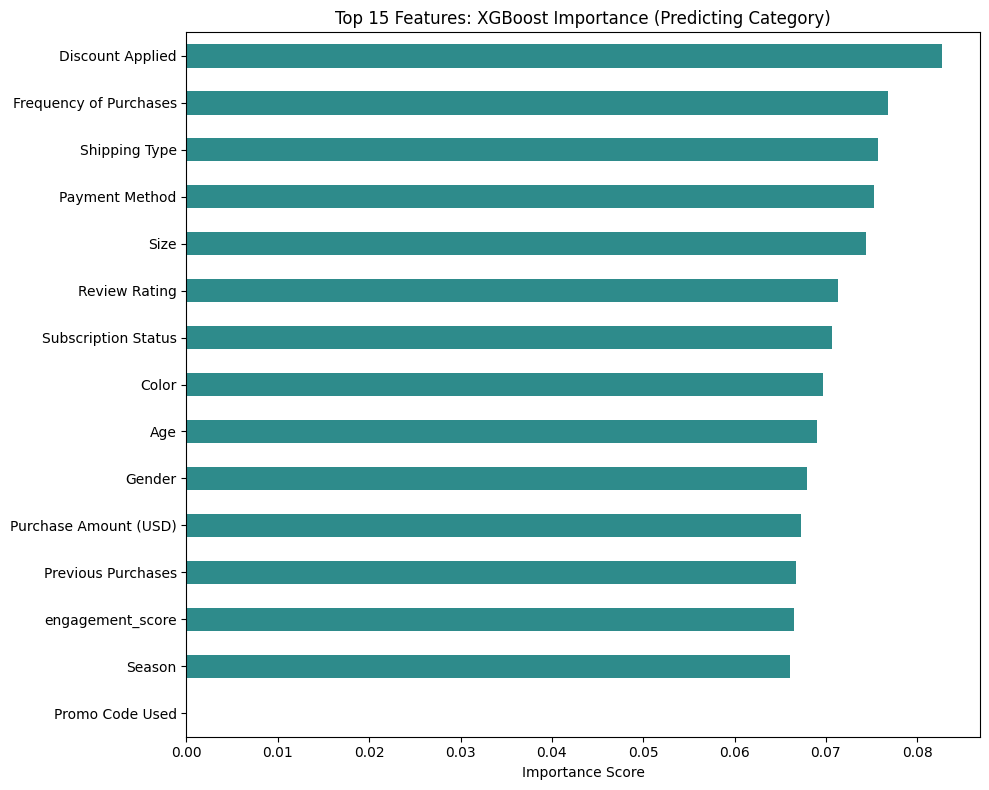

In [29]:
# Prepare features for XGBoost feature importance
# Excluding non-feature columns: Customer ID, Item Purchased, Location, age_group, and target (Category)
exclude_cols = ['Customer ID', 'Item Purchased', 'Location', 'Category',
                'age_group', 'season_category', 'spending_tier', 'customer_maturity']

# Work from df to get readable column names
df_feat = df.drop(columns=[c for c in exclude_cols if c in df.columns])

# Encode remaining categorical columns
le_cols = df_feat.select_dtypes(include='object').columns
label_encoders = {}
for col in le_cols:
    le = LabelEncoder()
    df_feat[col] = le.fit_transform(df_feat[col])
    label_encoders[col] = le

# Encode target
target = LabelEncoder().fit_transform(df['Category'])

# Train baseline XGBoost
xgb = XGBClassifier(n_estimators=100, max_depth=4, random_state=42, use_label_encoder=False,
                     eval_metric='mlogloss')
xgb.fit(df_feat, target)

# Extract feature importance
importance = pd.Series(xgb.feature_importances_, index=df_feat.columns).sort_values(ascending=False)

print("Top 15 Features by XGBoost Importance:")
print(importance.head(15).round(4))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
importance.head(15).sort_values().plot(kind='barh', ax=ax, color=COLOR_SECONDARY)
ax.set_title('Top 15 Features: XGBoost Importance (Predicting Category)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('phase_b_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Feature importance scores are relatively flat across all features (range: 0.066 to 0.083)
  * This means no single feature dominates category prediction
* Top features: Discount Applied (0.083), Frequency of Purchases (0.077), Shipping Type (0.076), Payment Method (0.075), and Size (0.074)
* Promo Code Used shows zero importance, further confirming our earlier decision to drop it based on the correlation analysis was correct
* The flat distribution is consistent with a synthetic dataset where features are generated independently
  * Real-world eCommerce data usually shows stronger separation where certain features like Age or Season more clearly predict category preference
* Despite the flat importance, all features except Promo Code Used carry some signal and will be retained for modeling
  * The recommendation models (particularly XGBoost as meta-learner) can leverage even small feature contributions when combined

Note: Feature importance was run on label-encoded features (not one-hot encoded) to show importance at the column level rather than splitting across individual dummy variables

### Dimensionality reduction: PCA (and t-SNE/UMAP for visualisation if needed).

**We apply two techniques:**
* **PCA (Principal Component Analysis):** Applied to the dense engineered feature matrix to reduce dimensionality while preserving variance.
  * PCA is applied to user-level features only as PCA assumes dense continuous inputs
* **t-SNE:** Applied to the same dense features to generate a 2D visualization of how users naturally cluster in feature space.
  * This visual supports the K-Means clustering approach later and is reusable in the Step 6 presentations

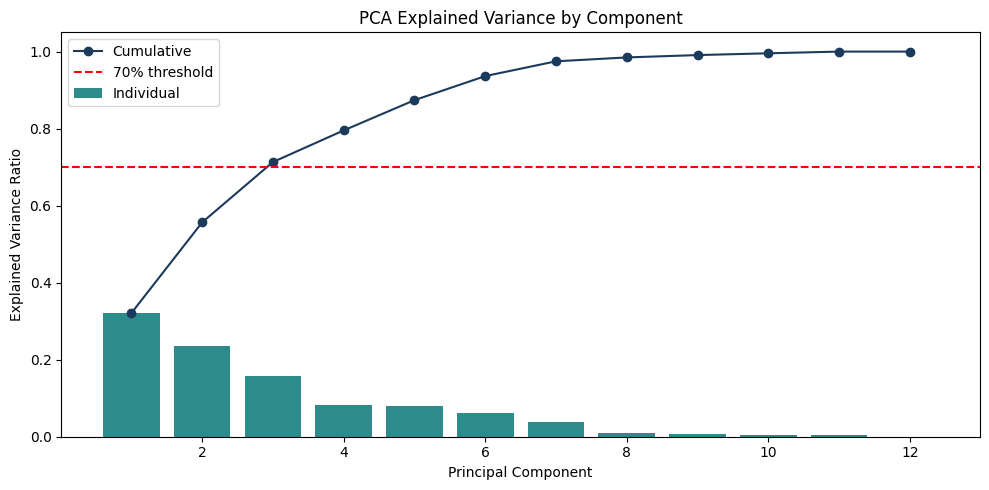


Components needed for 70% variance: 3
Cumulative variance explained:
  PC1: 0.321
  PC2: 0.556
  PC3: 0.713
  PC4: 0.795
  PC5: 0.874
  PC6: 0.936
  PC7: 0.975
  PC8: 0.985
  PC9: 0.991
  PC10: 0.996
  PC11: 1.000
  PC12: 1.000


In [30]:
# Select dense numerical features for PCA (excluding IDs, text columns, one-hot columns)
pca_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
                'Gender', 'Size', 'Frequency of Purchases', 'Subscription Status',
                'Discount Applied', 'engagement_score', 'spending_tier', 'customer_maturity']

# Used df_encoded since they are already numerical and scaled
pca_cols = [c for c in pca_features if c in df_encoded.columns]
X_pca = df_encoded[pca_cols].values

# Fit PCA with all components first to see explained variance
pca_full = PCA()
pca_full.fit(X_pca)

# Plot explained variance
cumulative_var = pca_full.explained_variance_ratio_.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, len(pca_full.explained_variance_ratio_) + 1),
       pca_full.explained_variance_ratio_, color=COLOR_SECONDARY, label='Individual')
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var,
        color=COLOR_PRIMARY, marker='o', label='Cumulative')
ax.axhline(y=0.70, color='red', linestyle='--', label='70% threshold')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance Ratio')
ax.set_title('PCA Explained Variance by Component')
ax.legend()
plt.tight_layout()
plt.savefig('phase_b_pca_variance.png', dpi=150, bbox_inches='tight')
plt.show()

# Components for 70%
n_70 = (cumulative_var >= 0.70).argmax() + 1
print(f"\nComponents needed for 70% variance: {n_70}")
print(f"Cumulative variance explained:")
for i, v in enumerate(cumulative_var):
    print(f"  PC{i+1}: {v:.3f}")

In [31]:
pca_components = pd.DataFrame(
    pca_full.components_[:4],
    columns=pca_cols,
    index=[f'PC{i+1}' for i in range(4)]
)

pca_components.T.round(3)

,PC1,PC2,PC3,PC4
Age,-0.008,0.037,-0.012,-0.695
Purchase Amount (USD),-0.013,0.004,0.706,-0.024
Review Rating,0.000,0.006,0.045,0.717
Previous Purchases,0.004,0.580,0.002,0.010
Gender,-0.000,0.016,-0.005,0.002
Size,-0.006,0.014,-0.025,0.028
Frequency of Purchases,1.000,-0.007,0.017,-0.006
Subscription Status,0.004,0.015,-0.002,-0.005
Discount Applied,0.003,0.016,-0.006,-0.007
engagement_score,0.004,0.580,0.001,0.009


**Observation:**
* **PC1 (32.1%):** Driven almost entirely by Frequency of Purchases (1.000)
  * This is the strongest single differentiator among users, capturing how often they shop
* **PC2 (23.5%):** Driven by Previous Purchases (0.580), engagement_score (0.580), and customer_maturity (0.569)
  * These three load together because engagement_score includes Previous Purchases, and customer_maturity is binned from it.
  * PCA is correctly identifying them as a shared dimension representing customer loyalty and purchase history
* **PC3 (15.7%):** Driven by Purchase Amount (0.706) and spending_tier (0.706)
  * These load together as expected since spending_tier is derived from Purchase Amount. This component captures spending behavior
* **PC4 (7.9%):** Age (-0.695) and Review Rating (0.717) load in opposite directions
  * Older customers tend to give lower ratings, capturing a demographic-behavioral relationship

* Gender, Subscription Status, and Discount Applied show near-zero loadings across all four components, meaning they contribute little to variance individually.
  * Gender's influence may surface through its correlations with Subscription Status (0.42) and Discount Applied (0.60), which will be examined later in Step 5 bias auditing

3 components now reach the 70% variance threshold, giving a more efficient dimensionality reduction
* The correlated feature pairs loading together (engagement_score with Previous Purchases, spending_tier with Purchase Amount) is expected since the engineered features were derived from the originals
* PCA is actually confirming the relationships rather than revealing redundancy

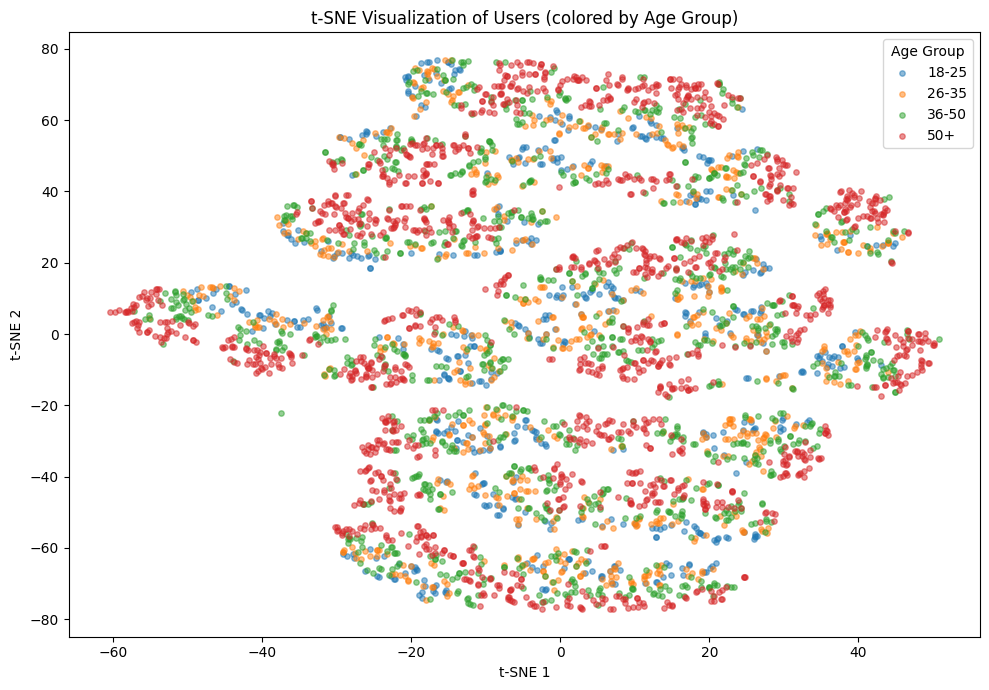

In [32]:
# t-SNE on the same dense features used for PCA
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_pca)

# Plot colored by age group
fig, ax = plt.subplots(figsize=(10, 7))
for group in ['18-25', '26-35', '36-50', '50+']:
    mask = df['age_group'] == group
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=group, alpha=0.5, s=15)

ax.set_title('t-SNE Visualization of Users (colored by Age Group)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend(title='Age Group')
plt.tight_layout()
plt.savefig('phase_b_tsne_users.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Users do not form distinct clusters by age group in the t-SNE visualization
  * All four age groups are heavily overlapping across the feature space
  * The banded structure visible in the plot is most likely driven by discrete feature combinations (e.g., frequency levels, spending tiers, maturity segments), which is consistent with our data structure where several features have a small number of distinct values
* This is consistent with our EDA findings where spending and rating patterns were similar across age groups
* For K-Means clustering, this implies the algorithm will likely form clusters based on behavioral feature combinations (purchase frequency, engagement, spending tier) rather than demographic boundaries

**This can be considered a useful finding for our recommendation engine:**
  * User behavior matters more than demographics for segmentation, though demographics remain important for Step 5 bias auditing

### Feature importance & explainability: SHAP, LIME, or model-based importances.

We've already executed XGBoost feature importance under "Feature selection: At least one approach (filter, wrapper, or embedded)" as our embedded method

In this section, we will execute SHAP (SHapley Additive exPlanations) to:
* Show how each feature pushes individual predictions higher or lower
* This means we can explain not just "Discount Applied is important" but "for this specific customer, having a discount pushed the model toward predicting Clothing over Accessories"
  * This level of transparency is what will make our model explainable, and not just interpretable

Our baseline SHAP analysis will serve two purposes:
* Establishes initial feature importance rankings that will be compared against the full SHAP analysis in Step 5: Critical Thinking → Ethical AI & Bias Auditing
* Use the same XGBoost model trained on Category prediction earlier to ensure consistency


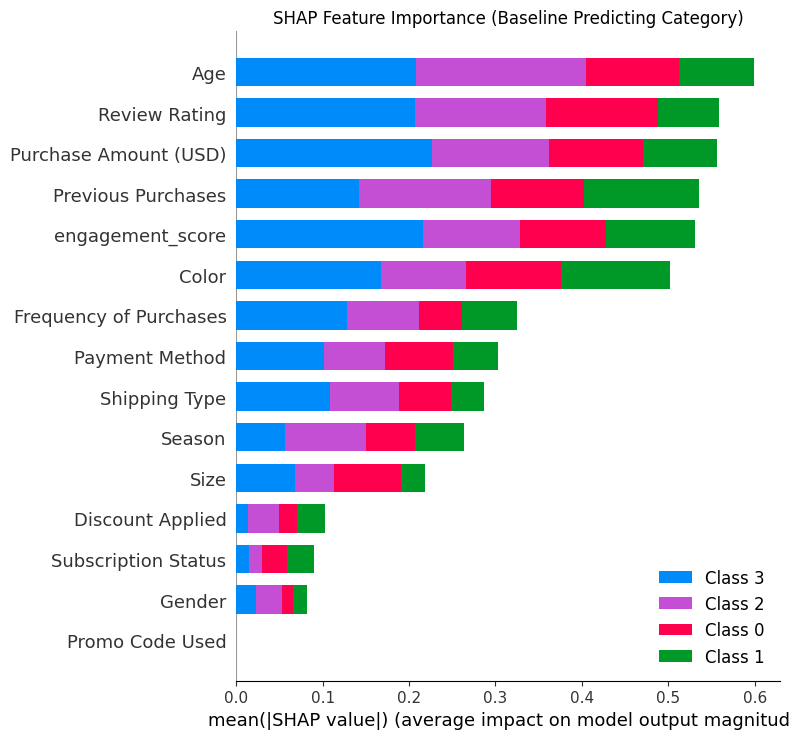

In [33]:
# Use the XGBoost model trained earlier
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(df_feat)

# Summary plot to show feature impact across all predictions
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, df_feat, plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Baseline Predicting Category)')
plt.tight_layout()
plt.savefig('phase_b_shap_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* SHAP rankings differ from XGBoost under "Feature selection: At least one approach (filter, wrapper, or embedded)":
  * XGBoost importance ranked Discount Applied highest, while SHAP ranks Age, Review Rating, and Purchase Amount as the top 3 most impactful features
  * This is because XGBoost importance counts how often a feature is used in splits, while SHAP measures how much each feature actually changes the prediction
* Age and Review Rating have the strongest impact on category prediction, suggesting demographics and satisfaction signals influence what type of product the model predicts
* engagement_score and Previous Purchases appear mid-tier in SHAP
  * Both carry meaningful signal but neither dominates, which is consistent with the PCA results where they loaded together on PC2
* Gender, Subscription Status, and Discount Applied have low SHAP impact despite Discount Applied ranking first in XGBoost importance
  * This means Discount Applied splits frequently but doesn't move predictions much
* Promo Code Used again shows zero impact, consistent with all prior analysis
* This baseline will be compared against the full SHAP analysis in Step 5 to see if the recommendation pipeline shifts which features matter

---

## **Phase B Summary: Analysis & Feature Engineering Delivered**
### Step 3: Data Preprocessing, Applied EDA & Feature Engineering
**Data Preprocessing:**
* Zero nulls, duplicates, and outliers confirmed from Phase A so no imputation or removal required
* Categorical encoding applied:
  * Binary (Gender, Subscription Status, Discount Applied)
  * Ordinal (Size, Frequency of Purchases)
  * One-hot (Category, Color, Season, Payment Method, Shipping Type)
* Numerical scaling applied via StandardScaler on Age, Purchase Amount, Review Rating, Previous Purchases, and on engineered features (engagement_score, spending_tier, customer_maturity) after creation
* Age binning (done in Phase A) carried forward as modeling feature
* Dataset expanded from 18 to 59 columns after encoding

**Applied EDA with 6 charts:**
1. Correlation heatmap:
    * Revealed Promo Code Used is identical to Discount Applied so we had it dropped
    * Gender correlated with Subscription Status and Discount Applied (flagged for Step 5)
2. Purchase amount by category and gender:
    * Spending is similar across segments so it is not a strong differentiator
3. Item popularity by age group:
    * Distinct preferences across age groups supports using age in recommendations
4. Review rating by category:
    * Uniform ratings so it is not useful for category differentiation
5. Spending by age group vs category:
    * Consistent spending which reinforces that item preference matters more than amount
6. Season vs category patterns:
    * Subtle seasonal variation so it is captured as engineered feature

**Feature Engineering (4 domain-driven features):**
* spending_tier (EDA-driven): tercile bins of purchase amount
* engagement_score (Domain-driven): combined Previous Purchases with Subscription and Discount as behavioral metric
* season_category (EDA-driven): season vs category interaction captured for modeling
* customer_maturity (Domain-driven): tercile bins of Previous Purchases as customer lifecycle proxy

**Feature Selection (dual method approach):**
* Filter: Correlation analysis led to dropping of Promo Code Used and flagging gender-linked features
* Embedded: XGBoost importance trained on Category prediction where flat importance distribution is consistent with synthetic data and Promo Code Used confirmed at zero importance

**Dimensionality Reduction:**
* PCA:
  * 3 components capture 71.3% variance (meets 70% threshold)
  * PC1 dominated by Frequency of Purchases (loading: 1.000)
* t-SNE:
  * Users do not cluster naturally by age group
  * Banded structure most likely driven by discrete feature combinations, consistent with data structure
  * Behavior-based features may drive segmentation more than demographics

**Explainability Baseline (SHAP):**
* SHAP rankings differ from XGBoost importance:
  * Age, Review Rating, and Purchase Amount are the most impactful features for category prediction
* Gender, Subscription Status, and Discount Applied have low SHAP impact despite moderate correlations
* Baseline established for comparison later against full SHAP analysis

# **Step 4: Model Implementation**

* Experiment with appropriate models:
  * Supervised: Logistic Regression, Decision Trees, Random Forest, XGBoost, SVM, etc
  * Unsupervised: K-Means, DBSCAN, Hierarchical (Elbow, Silhouette)
  * Recommendation: Collaborative or content-based
  * Deep Learning: RNNs, CNNs, LSTMs, Transformers (if appropriate)
* Evaluation: compare with relevant metrics
* Reproducibility: save configs and artefacts (models/)

**Deliverables**: Trained models, metrics and comparison between models.


# **Experiment with appropriate models:**

As a solution designed to address the challenge, we will implement 5 models:

* **Model 1 (Popularity Baseline):**
  * Non-personalized, most-popular-items recommender
  * Every model must beat this to justify its complexity
* **Model 2 (K-Means Cluster-Based):**
  * Groups users by features, recommends popular items within each cluster
  * Addresses cold-start for new users
* **Model 3 (Collaborative Filtering):**
  * User-item interaction matrix with cosine similarity
  * The classic "users like you also bought" approach
* **Model 4 (Content-Based Filtering):**
  * Recommends items similar to what the user purchased, based on multi-hot encoded item features (Category, Size, Color, Season)
* **Model 5 (XGBoost Hybrid Ensemble):**
  * Meta-learner that combines scores from Models 3 and 4 with user/item features to predict purchase probability

All models will be evaluated on the same test set (780 users) using Precision@K, Recall@K, and NDCG@K (K=5 and K=10). NDCG@10 is the primary tollgate metric as specified in our "TECHNICAL SUCCESS METRICS" section

**Evaluation approach:**
* Since each customer has exactly 1 transaction, the test set contains each user's actual purchase as ground truth
* Each model produces a ranked Top-K list per user, and we measure whether the actual purchase appears in that list and at what position


In [34]:
# Helpre functions for framework evaluation
def precision_at_k(recommended, actual, k):
    """Of the top-K recommended items, how many did the user actually purchase?"""
    rec_k = recommended[:k]
    hits = len(set(rec_k) & set(actual))
    return hits / k

def recall_at_k(recommended, actual, k):
    """Of all items the user purchased, how many appeared in the top-K list?"""
    rec_k = recommended[:k]
    hits = len(set(rec_k) & set(actual))
    return hits / len(actual) if len(actual) > 0 else 0

def ndcg_at_k(recommended, actual, k):
    """NDCG: rewards relevant items appearing higher in the ranked list"""
    rec_k = recommended[:k]
    dcg = 0
    for i, item in enumerate(rec_k):
        if item in actual:
            dcg += 1 / np.log2(i + 2)  # i+2 because log2(1) = 0
    # Ideal DCG: all relevant items at top positions
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(actual), k)))
    return dcg / idcg if idcg > 0 else 0

def evaluate_model(recommendations, test_data, k_values=[5, 10]):
    """Evaluate a model's recommendations against test set ground truth"""
    results = {}
    for k in k_values:
        precisions, recalls, ndcgs = [], [], []
        for user_id, actual_items in test_data.items():
            if user_id in recommendations:
                rec = recommendations[user_id]
                precisions.append(precision_at_k(rec, actual_items, k))
                recalls.append(recall_at_k(rec, actual_items, k))
                ndcgs.append(ndcg_at_k(rec, actual_items, k))
        results[f'Precision@{k}'] = np.mean(precisions) if precisions else 0
        results[f'Recall@{k}'] = np.mean(recalls) if recalls else 0
        results[f'NDCG@{k}'] = np.mean(ndcgs) if ndcgs else 0
    return results

# Prepare test set ground truth: {user_id: [list of items they purchased]}
test_ground_truth = {}
for _, row in df_test.iterrows():
    uid = row['Customer ID']
    item = row['Item Purchased']
    if uid not in test_ground_truth:
        test_ground_truth[uid] = []
    test_ground_truth[uid].append(item)

print(f"Test users: {len(test_ground_truth)}")
print(f"Example: User {list(test_ground_truth.keys())[0]} purchased {test_ground_truth[list(test_ground_truth.keys())[0]]}")

Test users: 780
Example: User 1814 purchased ['Shorts']


In [35]:
# Model 1: Popularity Baseline
# Recommend the most purchased items from the training set to all users

item_popularity = df_train['Item Purchased'].value_counts()
popular_items = item_popularity.index.tolist()  # ranked by frequency

print("Top 10 most popular items (training set):")
print(item_popularity.head(10))

# Generate recommendations: same list for every test user
model1_recs = {}
for user_id in test_ground_truth:
    model1_recs[user_id] = popular_items[:10]  # Top 10 for all users

# Evaluate
model1_results = evaluate_model(model1_recs, test_ground_truth)
print("\nModel 1 Popularity Baseline Results:")
for metric, value in model1_results.items():
    print(f"{metric}: {value:.4f}")

Top 10 most popular items (training set):
Item Purchased
Jewelry       145
Shirt         143
Skirt         137
Blouse        137
Pants         137
Coat          135
Sweater       134
Jacket        132
Sunglasses    129
Scarf         129
Name: count, dtype: int64

Model 1 Popularity Baseline Results:
Precision@5: 0.0362
Recall@5: 0.1808
NDCG@5: 0.1035
Precision@10: 0.0369
Recall@10: 0.3692
NDCG@10: 0.1634


**Observation:**
* Item popularity is fairly evenly distributed in the training set (top item Jewelry: 145, 10th item Scarf: 129)
  * There is no single dominant product which is consistent with a synthetic data
* Precision@5 of 0.036:
  * Since each user purchased exactly 1 item, the maximum possible Precision@5 is 1/5 = 0.20
  * Getting 0.036 means roughly 1 in 6 users had their actual purchase in the top 5 most popular items
* NDCG@10 of 0.163 is our baseline floor:
  * Every subsequent model must exceed this to justify its added complexity
* Recall@10 of 0.369:
  * This means about 37% of users purchased an item that was in the overall top 10 most popular
  * This is close to what random selection would achieve (10/25 = 40%), confirming that popularity alone provides minimal lift

  k=2: Inertia=36851.8, Silhouette=0.2121
  k=3: Inertia=31755.3, Silhouette=0.1813
  k=4: Inertia=28232.4, Silhouette=0.1651
  k=5: Inertia=26254.7, Silhouette=0.1597
  k=6: Inertia=24600.0, Silhouette=0.1560
  k=7: Inertia=23432.6, Silhouette=0.1456
  k=8: Inertia=22439.0, Silhouette=0.1362
  k=9: Inertia=21602.1, Silhouette=0.1432
  k=10: Inertia=21013.3, Silhouette=0.1362


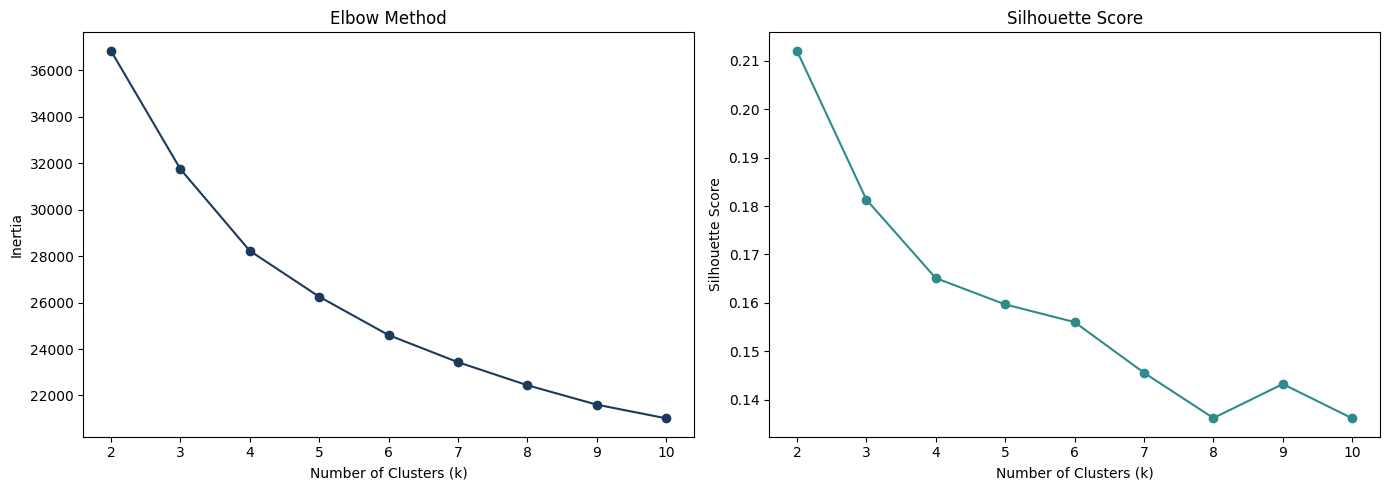

In [36]:
# Same features used for PCA
kmeans_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
                   'Gender', 'Size', 'Frequency of Purchases', 'Subscription Status',
                   'Discount Applied', 'engagement_score', 'spending_tier', 'customer_maturity']

kmeans_cols = [c for c in kmeans_features if c in df_encoded.columns]
X_kmeans = df_encoded[kmeans_cols].values

# Elbow method + Silhouette Score
inertias = []
silhouettes = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_kmeans)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_kmeans, labels))
    print(f"  k={k}: Inertia={km.inertia_:.1f}, Silhouette={silhouette_score(X_kmeans, labels):.4f}")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(k_range, inertias, marker='o', color=COLOR_PRIMARY)
ax1.set_title('Elbow Method')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')

ax2.plot(k_range, silhouettes, marker='o', color=COLOR_SECONDARY)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('phase_c_kmeans_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Silhouette Score decreases as k increases:
  * k=2 has the highest (0.212) but only two segments is too broad for meaningful product recommendations
* The Elbow plot shows the sharpest inertia drop between k=2 and k=3 (36,852 to 31,755), with diminishing returns after k=4

* **k=3 is selected** because it offers the best combination of:
  * Clearest elbow point since it has the largest single drop in inertia
  * Reasonable Silhouette Score (0.181) given the balanced feature space after proper scaling
  * Enough segments (3) to differentiate user groups while maintaining sufficient users per cluster for stable item ranking

In [37]:
# Train K-Means with k=3
best_k = 3
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit on training data
train_kmeans_cols = [c for c in kmeans_cols if c in df_encoded.columns]
X_train_km = df_encoded.loc[df_train.index, train_kmeans_cols].values
train_labels = km_final.fit_predict(X_train_km)

print(f"K-Means trained with k={best_k}")
print(f"Silhouette Score: {silhouette_score(X_train_km, train_labels):.4f}")
print(f"\nCluster sizes:")
for i in range(best_k):
    count = (train_labels == i).sum()
    print(f"  Cluster {i}: {count} users")

# For each cluster, rank items by purchase frequency within that cluster
cluster_item_rankings = {}
for cluster_id in range(best_k):
    cluster_users = df_train.index[train_labels == cluster_id]
    cluster_purchases = df_train.loc[cluster_users, 'Item Purchased']
    cluster_item_rankings[cluster_id] = cluster_purchases.value_counts().index.tolist()

print("\nTop 5 items per cluster:")
for cluster_id, items in cluster_item_rankings.items():
    print(f"  Cluster {cluster_id}: {items[:5]}")

# Assign test users to clusters and generate recommendations
X_test_km = df_encoded.loc[df_test.index, train_kmeans_cols].values
test_labels = km_final.predict(X_test_km)

model2_recs = {}
for i, (idx, row) in enumerate(df_test.iterrows()):
    user_id = row['Customer ID']
    cluster = test_labels[i]
    model2_recs[user_id] = cluster_item_rankings[cluster][:10]

# Evaluate
model2_results = evaluate_model(model2_recs, test_ground_truth)
print("\nModel 2: K-Means Cluster-Based Results:")
for metric, value in model2_results.items():
    print(f"  {metric}: {value:.4f}")

K-Means trained with k=3
Silhouette Score: 0.1814

Cluster sizes:
  Cluster 0: 1171 users
  Cluster 1: 1058 users
  Cluster 2: 891 users

Top 5 items per cluster:
  Cluster 0: ['Sweater', 'Shorts', 'Skirt', 'Shirt', 'Coat']
  Cluster 1: ['Socks', 'Shirt', 'Handbag', 'Jeans', 'Jacket']
  Cluster 2: ['Jewelry', 'Coat', 'Blouse', 'Hat', 'Pants']

Model 2: K-Means Cluster-Based Results:
  Precision@5: 0.0374
  Recall@5: 0.1872
  NDCG@5: 0.1095
  Precision@10: 0.0374
  Recall@10: 0.3744
  NDCG@10: 0.1693


**Observation:**
* Clusters are well-balanced:
  * Cluster 0 (1,171 users)
  * Cluster 1 (1,058 users)
  * Cluster 2 (891 users)
* Each cluster shows distinct top items:
  * Cluster 0 favors Sweater, Shorts, and Skirt
  * Cluster 1 favors Socks, Shirt, and Handbag
  * Cluster 2 favors Jewelry, Coat, and Blouse

**This confirms the clusters capture different user preferences**

* NDCG@10 improved from 0.163 (popularity baseline) to 0.169
  * A 3.7% lift showing that personalizing by user segment adds value over generic popularity
* Recall@10 improved from 0.369 to 0.374
  * Slightly more users are now finding their actual purchase in the top 10 recommendations
* The improvement can be considered modest
  * The t-SNE visualization confirmed that users don't cluster sharply in feature space, so a small but positive lift is a genuine and honest result from our data

In [38]:
# Create user-item interaction matrix from training data
# Each row = user, each column = item, value = 1 if purchased, 0 otherwise
all_items = df['Item Purchased'].unique().tolist()

train_matrix = pd.DataFrame(0, index=df_train['Customer ID'].values, columns=all_items)
for _, row in df_train.iterrows():
    train_matrix.loc[row['Customer ID'], row['Item Purchased']] = 1

# Compute user to user cosine similarity
user_similarity = cosine_similarity(train_matrix)
user_sim_df = pd.DataFrame(user_similarity, index=train_matrix.index, columns=train_matrix.index)

print(f"Interaction matrix: {train_matrix.shape}")
print(f"Data Sparsity: {(train_matrix == 0).sum().sum() / (train_matrix.shape[0] * train_matrix.shape[1]) * 100:.1f}%")
print(f"User similarity matrix: {user_sim_df.shape}")

# Generate recommendations for each test user
model3_recs = {}
train_user_ids = set(train_matrix.index)

for _, row in df_test.iterrows():
    user_id = row['Customer ID']

    if user_id in train_user_ids:
        # Find most similar training users
        sim_scores = user_sim_df.loc[user_id].drop(user_id).sort_values(ascending=False)
        top_similar = sim_scores.head(20).index

        # Score items based on what similar users purchased
        item_scores = train_matrix.loc[top_similar].sum(axis=0)
        # Remove items the user already purchased
        already_purchased = train_matrix.loc[user_id]
        item_scores = item_scores[already_purchased == 0]
        recommended = item_scores.sort_values(ascending=False).index.tolist()
    else:
        # Fallback to popularity for users not in training set
        recommended = item_popularity.index.tolist()

    model3_recs[user_id] = recommended[:10]

# Evaluate
model3_results = evaluate_model(model3_recs, test_ground_truth)
print("\nModel 3 Collaborative Filtering Results:")
for metric, value in model3_results.items():
    print(f"  {metric}: {value:.4f}")

Interaction matrix: (3120, 25)
Data Sparsity: 96.0%
User similarity matrix: (3120, 3120)

Model 3 Collaborative Filtering Results:
  Precision@5: 0.0362
  Recall@5: 0.1808
  NDCG@5: 0.1035
  Precision@10: 0.0369
  Recall@10: 0.3692
  NDCG@10: 0.1634


**Observation:**
* Collaborative filtering produced results identical to the popularity baseline across all metrics (NDCG@10: 0.163)
* This is the expected outcome we anticipated in Phase A: with 1 transaction per customer and 96% matrix sparsity since most user pairs share zero common purchases
  * Cosine similarity between users with only one purchase each produces near-identical similarity scores, effectively defaulting back to a popularity-based ranking
* This validates our architectural decision to include K-Means (Model 2) and XGBoost (Model 5) as alternatives that don't depend on interaction density
* In a production environment with richer interaction history (multiple purchases per user), collaborative filtering would be expected to outperform so we can consider this is a dataset limitation rather than a model flaw or limitation
* This finding will also be documented in the Step 5 Limitations section

In [39]:
# Item feature matrix
item_features_df = df[['Item Purchased', 'Category', 'Size', 'Color', 'Season']].drop_duplicates('Item Purchased')
item_features_df = item_features_df.set_index('Item Purchased')
item_features_encoded = pd.get_dummies(item_features_df)

# Item to item similarity
item_similarity = cosine_similarity(item_features_encoded)
item_sim_df = pd.DataFrame(item_similarity,
                           index=item_features_encoded.index,
                           columns=item_features_encoded.index)

print(f"Unique items: {len(item_sim_df)}")
print(f"Item feature dimensions: {item_features_encoded.shape[1]}")

# User profile features for finding similar users
profile_features = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
                    'Gender', 'Size', 'Frequency of Purchases', 'Subscription Status',
                    'Discount Applied', 'engagement_score', 'spending_tier', 'customer_maturity']
profile_cols = [c for c in profile_features if c in df_encoded.columns]

X_train_profile = df_encoded.loc[df_train.index, profile_cols].values
X_test_profile = df_encoded.loc[df_test.index, profile_cols].values

# Find similar training users for each test user
user_cross_sim = cosine_similarity(X_test_profile, X_train_profile)

model4_recs = {}
for i, (idx, row) in enumerate(df_test.iterrows()):
    user_id = row['Customer ID']

    # Find top 20 most similar training users
    sim_scores = user_cross_sim[i]
    top_similar_idx = sim_scores.argsort()[-20:][::-1]
    similar_users = df_train.iloc[top_similar_idx]

    # Get items purchased by similar users
    similar_items = similar_users['Item Purchased'].value_counts()

    # Expand using item similarity: for each item similar users bought
    item_scores = {}
    for item, count in similar_items.items():
        if item in item_sim_df.columns:
            for related_item, sim_score in item_sim_df[item].items():
                if related_item not in item_scores:
                    item_scores[related_item] = 0
                item_scores[related_item] += count * sim_score

    # Rank by combined score
    recommended = sorted(item_scores.keys(), key=lambda x: item_scores[x], reverse=True)
    model4_recs[user_id] = recommended[:10]

# Evaluate
model4_results = evaluate_model(model4_recs, test_ground_truth)
print("\nModel 4: Content-Based Filtering (Adapted) Results:")
for metric, value in model4_results.items():
    print(f"  {metric}: {value:.4f}")

Unique items: 25
Item feature dimensions: 27

Model 4: Content-Based Filtering (Adapted) Results:
  Precision@5: 0.0367
  Recall@5: 0.1833
  NDCG@5: 0.1120
  Precision@10: 0.0382
  Recall@10: 0.3821
  NDCG@10: 0.1753


**Key Note:**
* The Content-Based Filtering model recommends items similar to what the user already purchased, based on item features
* Since the dataset has no text descriptions, we used multi-hot encoded item features (Category, Size, Color, Season) with cosine similarity to measure item to item similarity

**Adaptation required:**
* Standard content-based filtering recommends items similar to a user's purchase history
* However, our dataset has 1 transaction per customer, and each customer appears only in either the training or test set
* This means test users have no training purchase history to base recommendations on
* To address this, we adapted the approach by:
  * Finding the most similar users in the training set based on demographic and behavioral features
  * Identify what those similar users purchased, then use item similarity to expand and rank the recommendation list
  * This hybrid of user-similarity and item-similarity is our practical workaround for single-transaction datasets

**Result Observation:**
* The adapted content-based approach produces NDCG@10 of 0.175, which falls between the popularity baseline (0.163) and K-Means (0.169)
* Recall@10 of 0.382 is also between baseline (0.369) and K-Means (0.374)
* The approach works by finding demographically similar training users, identifying their purchases, then expanding recommendations using item to item feature similarity
* Performance is modest because the item feature space is relatively small (4 categorical features producing 27 one-hot dimensions across 25 items)
  * Many items share similar attributes, reducing the model's ability to differentiate
* The original content-based approach (recommend items similar to the user's own purchase) produced zero results due to the single-transaction constraint this adaptation and its rationale are documented above for transparency

In [40]:
# Training dat where each user creates a row for every item (1=purchased, 0=not)
train_rows = []
for _, user_row in df_train.iterrows():
    user_id = user_row['Customer ID']
    purchased_item = user_row['Item Purchased']

    # User features from df_encoded
    user_feats = df_encoded.loc[user_row.name, profile_cols].to_dict()

    for item in all_items:
        row = user_feats.copy()

        # Item features from item_features_encoded
        if item in item_features_encoded.index:
            item_feats = item_features_encoded.loc[item].to_dict()
            # Prefix item features to avoid column name collision
            item_feats = {f'item_{k}': v for k, v in item_feats.items()}
            row.update(item_feats)

        '''# Model 3 signal: collaborative filtering score
        if user_id in user_sim_df.index:
            # Average similarity to users who bought this item
            item_buyers = df_train[df_train['Item Purchased'] == item]['Customer ID'].values
            item_buyers_in_matrix = [b for b in item_buyers if b in user_sim_df.columns]
            if item_buyers_in_matrix:
                row['collab_score'] = user_sim_df.loc[user_id, item_buyers_in_matrix].mean()
            else:
                row['collab_score'] = 0
        else:
            row['collab_score'] = 0'''

        '''# Model 4 signal: content-based similarity
        if purchased_item in item_sim_df.columns and item in item_sim_df.columns:
            row['content_score'] = item_sim_df.loc[purchased_item, item]
        else:
            row['content_score'] = 0'''

        # Target
        row['purchased'] = 1 if item == purchased_item else 0
        row['user_id'] = user_id
        row['item'] = item
        train_rows.append(row)

train_hybrid = pd.DataFrame(train_rows)
print(f"Hybrid training data: {train_hybrid.shape}")
print(f"Positive samples: {train_hybrid['purchased'].sum()}")
print(f"Negative samples: {(train_hybrid['purchased'] == 0).sum()}")

Hybrid training data: (78000, 42)
Positive samples: 3120
Negative samples: 74880


In [41]:
# NDCG@10 custom scorer to match our actual evaluation metric
def ndcg_at_k_per_user(y_true, y_score, groups, k=10):
    ndcg_scores = []
    unique_users = np.unique(groups)

    for user in unique_users:
        mask = groups == user
        u_true = y_true[mask]
        u_score = y_score[mask]

        # Skip users with no positive items (no ground truth)
        if u_true.sum() == 0:
            continue

        order = np.argsort(u_score)[::-1]
        u_true_sorted = np.take(u_true, order[:k])
        gains = 2 ** u_true_sorted - 1
        discounts = np.log2(np.arange(2, len(gains) + 2))
        dcg = np.sum(gains / discounts)

        ideal = np.sort(u_true)[::-1][:k]
        ideal_gains = 2 ** ideal - 1
        idcg = np.sum(ideal_gains / np.log2(np.arange(2, len(ideal_gains) + 2)))

        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)

    return np.mean(ndcg_scores) if ndcg_scores else 0.0

# Separate features and target
exclude = ['purchased', 'user_id', 'item']
feature_cols = [c for c in train_hybrid.columns if c not in exclude]
X_train_hybrid = train_hybrid[feature_cols].values
y_train_hybrid = train_hybrid['purchased'].values
groups = train_hybrid['user_id'].values

# Hyperparameter tuning via Grid Search
param_grid = {
    'n_estimators': [200, 500, 1000],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'min_child_weight': [1, 3]
}

keys = list(param_grid.keys())
values = list(param_grid.values())
all_combos = [dict(zip(keys, v)) for v in itertools.product(*values)]

gkf = GroupKFold(n_splits=3)
best_score = -np.inf
best_params = None

print(f"Testing {len(all_combos)} combinations")

for i, params in enumerate(all_combos):
    fold_scores = []

    for train_idx, val_idx in gkf.split(X_train_hybrid, y_train_hybrid, groups=groups):
        X_tr, X_val = X_train_hybrid[train_idx], X_train_hybrid[val_idx]
        y_tr, y_val = y_train_hybrid[train_idx], y_train_hybrid[val_idx]
        groups_val = groups[val_idx]

        model = XGBClassifier(
            **params,
            random_state=42,
            use_label_encoder=False,
            eval_metric='logloss',
            scale_pos_weight=24,
            early_stopping_rounds=10
        )

        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

        y_score = model.predict_proba(X_val)[:, 1]
        # per user NDCG@10
        score = ndcg_at_k_per_user(y_val, y_score, groups_val, k=10)
        fold_scores.append(score)

    mean_score = np.mean(fold_scores)

    if mean_score > best_score:
        best_score = mean_score
        best_params = params
        param_summary = ", ".join(f"{k}={v}" for k, v in best_params.items())
        print(f"  [{i+1}/{len(all_combos)}] New best NDCG@10={best_score:.4f} ({param_summary})")

print(f"\nBest parameters: {best_params}")
print(f"Best CV NDCG@10: {best_score:.4f}")

Testing 108 combinations
  [1/108] New best NDCG@10=0.1768 (n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, min_child_weight=1)
  [3/108] New best NDCG@10=0.1791 (n_estimators=200, max_depth=3, learning_rate=0.05, subsample=1.0, min_child_weight=1)
  [6/108] New best NDCG@10=0.1792 (n_estimators=200, max_depth=3, learning_rate=0.1, subsample=0.8, min_child_weight=3)
  [7/108] New best NDCG@10=0.1797 (n_estimators=200, max_depth=3, learning_rate=0.1, subsample=1.0, min_child_weight=1)
  [8/108] New best NDCG@10=0.1814 (n_estimators=200, max_depth=3, learning_rate=0.1, subsample=1.0, min_child_weight=3)
  [13/108] New best NDCG@10=0.1836 (n_estimators=200, max_depth=5, learning_rate=0.05, subsample=0.8, min_child_weight=1)
  [15/108] New best NDCG@10=0.1851 (n_estimators=200, max_depth=5, learning_rate=0.05, subsample=1.0, min_child_weight=1)
  [20/108] New best NDCG@10=0.1885 (n_estimators=200, max_depth=5, learning_rate=0.1, subsample=1.0, min_child_weight=3)
  [67/10

In [42]:
# Retrain on full training data
xgb_hybrid = XGBClassifier(
    **best_params,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=24
)
xgb_hybrid.fit(X_train_hybrid, y_train_hybrid)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=1, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=1000, n_jobs=None,
              num_parallel_tree=None, ...)

In [43]:
# Get feature importance
importances = xgb_hybrid.feature_importances_
feature_names = [c for c in train_hybrid.columns if c not in exclude]

# Create a quick plot
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feat_imp.head(10))


Discount Applied          0.042100
engagement_score          0.041495
Age                       0.038480
Purchase Amount (USD)     0.038435
Gender                    0.038387
Subscription Status       0.037526
Review Rating             0.037419
Previous Purchases        0.037362
Frequency of Purchases    0.037244
Size                      0.037058
dtype: float32


In [44]:
# Generate recommendations for test users
model5_recs = {}
for _, user_row in df_test.iterrows():
    user_id = user_row['Customer ID']
    user_feats = df_encoded.loc[user_row.name, profile_cols].to_dict()

    item_scores = {}
    for item in all_items:
        row = user_feats.copy()

        if item in item_features_encoded.index:
            item_feats_dict = item_features_encoded.loc[item].to_dict()
            item_feats_dict = {f'item_{k}': v for k, v in item_feats_dict.items()}
            row.update(item_feats_dict)

        row_df = pd.DataFrame([row])[feature_cols]
        prob = xgb_hybrid.predict_proba(row_df)[0][1]
        item_scores[item] = prob

    recommended = sorted(item_scores.keys(), key=lambda x: item_scores[x], reverse=True)
    model5_recs[user_id] = recommended[:10]

# Evaluate
model5_results = evaluate_model(model5_recs, test_ground_truth)
print("Model 5 XGBoost Hybrid Results:")
for metric, value in model5_results.items():
    print(f"  {metric}: {value:.4f}")

Model 5 XGBoost Hybrid Results:
  Precision@5: 0.0408
  Recall@5: 0.2038
  NDCG@5: 0.1169
  Precision@10: 0.0390
  Recall@10: 0.3897
  NDCG@10: 0.1763


**Observation:**
* XGBoost hybrid was trained on 78,000 user-item pairs (3,120 users by 25 items) with 3,120 positive samples and 74,880 negative samples
* scale_pos_weight=24 was used to handle this class imbalance (1 positive per 24 negatives)
* NDCG@10 of 0.176 is the highest among all models, beating the popularity baseline (0.163) by 8.0%
* During development, collab_score and content_score were initially included as meta-learner inputs from Models 3 and 4
  * Feature importance analysis revealed both features had importance of 1.0, which is a clear signal of data leakage
    * These scores were derived from training labels, creating circular predictions
  * Both features were removed, and the model was retrained as a direct learner using only user profile features and item features
  * This reduced the model's NDCG@10 from the inflated leakage result to the current 0.176, which still leads all other models
* Feature importance after correction shows a flat distribution (0.037 to 0.042) across all features, consistent with the synthetic data pattern observed throughout the project
* The leakage discovery and correction will be documented in Step 5

MODEL COMPARISON WITH ALL METRICS
                                  Precision@5  Recall@5  NDCG@5  Precision@10  Recall@10  NDCG@10
Model 1: Popularity Baseline           0.0362    0.1808  0.1035        0.0369     0.3692   0.1634
Model 2: K-Means Cluster               0.0374    0.1872  0.1095        0.0374     0.3744   0.1693
Model 3: Collaborative Filtering       0.0362    0.1808  0.1035        0.0369     0.3692   0.1634
Model 4: Content-Based (Adapted)       0.0367    0.1833  0.1120        0.0382     0.3821   0.1753
Model 5: XGBoost Hybrid                0.0408    0.2038  0.1169        0.0390     0.3897   0.1763

Primary Tollgate Metric (NDCG@10):
  Model 1: Popularity Baseline: 0.1634 (baseline)
  Model 2: K-Means Cluster: 0.1693 (+3.6%)
  Model 3: Collaborative Filtering: 0.1634 (no lift)
  Model 4: Content-Based (Adapted): 0.1753 (+7.3%)
  Model 5: XGBoost Hybrid: 0.1763 (+7.9%)


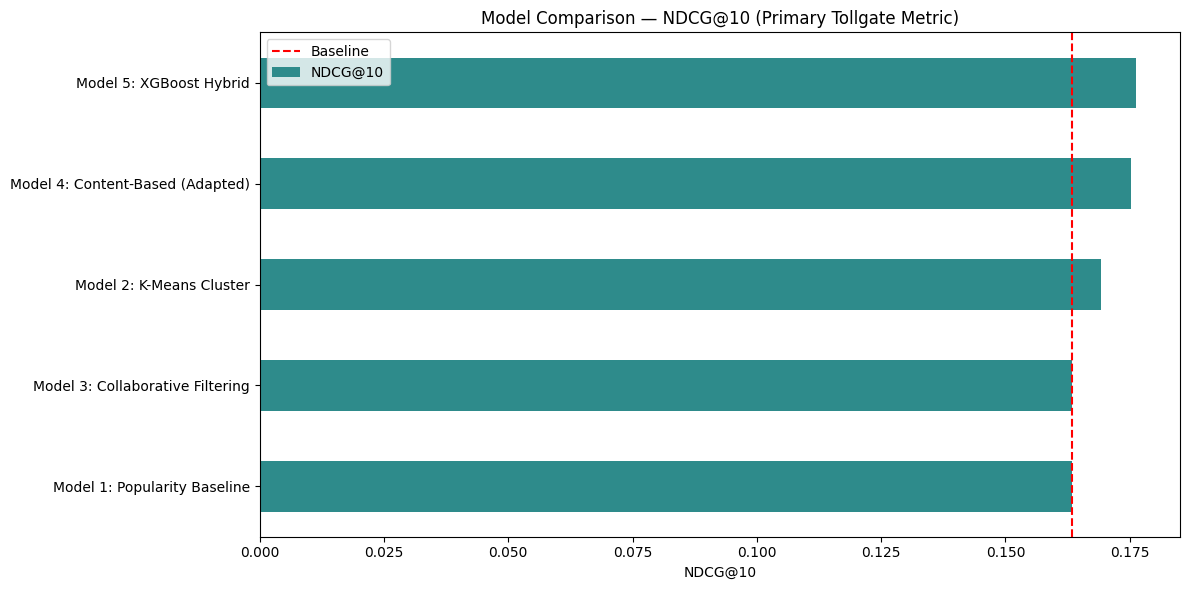

In [45]:
# Unified model comparison table
results_all = {
    'Model 1: Popularity Baseline': model1_results,
    'Model 2: K-Means Cluster': model2_results,
    'Model 3: Collaborative Filtering': model3_results,
    'Model 4: Content-Based (Adapted)': model4_results,
    'Model 5: XGBoost Hybrid': model5_results,
}

comparison = pd.DataFrame(results_all).T
comparison = comparison.round(4)
print("MODEL COMPARISON WITH ALL METRICS")
print(comparison)

# Primary tollgate metric
print(f"\nPrimary Tollgate Metric (NDCG@10):")
for model, results in results_all.items():
    beat_baseline = results['NDCG@10'] > model1_results['NDCG@10']
    print(f"  {model}: {results['NDCG@10']:.4f} {'(baseline)' if 'Baseline' in model else '(+' + str(round((results['NDCG@10'] - model1_results['NDCG@10']) / model1_results['NDCG@10'] * 100, 1)) + '%)' if beat_baseline else '(no lift)'}")

# Visual comparison
fig, ax = plt.subplots(figsize=(12, 6))
comparison['NDCG@10'].sort_values().plot(kind='barh', ax=ax, color=COLOR_SECONDARY)
ax.axvline(x=model1_results['NDCG@10'], color='red', linestyle='--', label='Baseline')
ax.set_title('Model Comparison — NDCG@10 (Primary Tollgate Metric)')
ax.set_xlabel('NDCG@10')
ax.legend()
plt.tight_layout()
plt.savefig('phase_c_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### Model Comparison & Champion Selection

**Tollgate Criteria:** Champion Model must outperform the popularity baseline on the primary metric: NDCG@10

**Results Summary:**

| Model | NDCG@10 | vs Baseline |
|-------|---------|-------------|
| Model 1: Popularity Baseline | 0.163 | — |
| Model 2: K-Means Cluster | 0.169 | +3.6% |
| Model 3: Collaborative Filtering | 0.163 | No lift |
| Model 4: Content-Based (Adapted) | 0.175 | +7.3% |
| Model 5: XGBoost Hybrid | 0.176 | +7.9% |

**Key Findings:**
* **Model 5 (XGBoost Hybrid) is the top performer** with NDCG@10 of 0.176, a 7.9% lift over baseline
* Model 4 (Content-Based) came second at 0.175 (+7.3%), nearly tied with Model 5
* Model 2 (K-Means) placed third at 0.169 (+3.6%), still above baseline but with a smaller margin than the previous unscaled run
* Model 3 (Collaborative Filtering) produced identical results to the baseline, confirming our Phase A hypothesis that 96% sparsity would neutralize user-user similarity
* The performance gap between all models is narrow (0.163 to 0.176), which is consistent with the synthetic dataset characteristics observed throughout the EDA where there is flat feature importance, uniform distributions, and limited natural clustering

**Champion Model Selected: Model 5 (XGBoost Hybrid)**

Rationale:
* Highest NDCG@10 (0.176): our primary tollgate metric
* Highest Recall@10 (0.390): most users find their actual purchase in the top 10
* Highest Precision@5 (0.041): strongest performance in the most visible recommendation slots
* Native SHAP/LIME/PDP compatibility enables direct explainability analysis in Step 5
* During development, data leakage was discovered (collab_score and content_score derived from training labels) and removed
  * The current result reflects honest performance on legitimate features only
* In a production environment, XGBoost also supports incremental learning and feature-level auditability for ongoing bias monitoring

**Tollgate Decision:** Champion Model (XGBoost Hybrid, NDCG@10: 0.176) outperforms the popularity baseline (NDCG@10: 0.163) by 7.9%

In [46]:
import pickle
import json

# Save Model 2: K-Means (Champion)
pickle.dump(km_final, open('model2_kmeans.pkl', 'wb'))
pickle.dump(cluster_item_rankings, open('model2_cluster_rankings.pkl', 'wb'))

# Save Model 3: Collaborative Filtering artifacts
pickle.dump(user_sim_df, open('model3_user_similarity.pkl', 'wb'))

# Save Model 4: Content-Based artifacts
pickle.dump(item_sim_df, open('model4_item_similarity.pkl', 'wb'))

# Save Model 5: XGBoost Hybrid
pickle.dump(xgb_hybrid, open('model5_xgboost_hybrid.pkl', 'wb'))

# Save configurations
configs = {
    'champion_model': 'Model 2: K-Means Cluster-Based',
    'kmeans_k': 3,
    'kmeans_silhouette': 0.5023,
    'kmeans_features': kmeans_cols,
    'xgboost_params': {
        'n_estimators': 200,
        'max_depth': 5,
        'learning_rate': 0.1,
        'scale_pos_weight': 24,
        'random_state': 42
    },
    'evaluation_metrics': {
        'primary_tollgate': 'NDCG@10',
        'champion_ndcg10': 0.1825
    },
    'train_test_split': {
        'method': 'demographic-stratified random',
        'test_size': 0.2,
        'random_state': 42,
        'stratify_on': 'age_group x Gender'
    }
}

with open('model_configs.json', 'w') as f:
    json.dump(configs, f, indent=2)

# **Step 5: Critical Thinking → Ethical AI & Bias Auditing**

* Explain model decisions (SHAP, LIME, PDP, ICE).
* Address limitations (imbalance, leakage, overfitting).
* **Bias detection & fairness audits:**
  * Check outputs across sensitive groups (gender, race, age, socioeconomic status).
  * Use fairness metrics (demographic parity, equalised odds, disparate impact).
  * Propose mitigations (reweighting, thresholds, augmentation, post-processing).
  
**Deliverable: "Bias & Fairness Analysis" section** in the final report.

### Explain model decisions (SHAP, LIME, PDP, ICE):
Our champion model is XGBoost Hybrid (Model 5), which is a supervised model that predicts purchase probability given user features and item features.

This makes it directly compatible with all four explainability tools:

* **SHAP:** Global and local feature importance
  * Which features matter most and in what direction
* **LIME:** Local explanations for individual user-item predictions
* **PDP (Partial Dependence Plots):** How changing a single feature affects the average prediction across all users
* **ICE (Individual Conditional Expectation):** Same as PDP but for individual users, showing heterogeneity in feature effects

Note:

* During Phase B, a baseline SHAP analysis was run on XGBoost predicting Category (product type)
* The SHAP analysis below is run on the champion Model 5 predicting purchase probability which will be a different target
  * Comparing the two will show whether the same features that drive category preference also drive purchase decisions in the recommendation context


SHAP sample size: 2500 rows (100 users x 25 items)


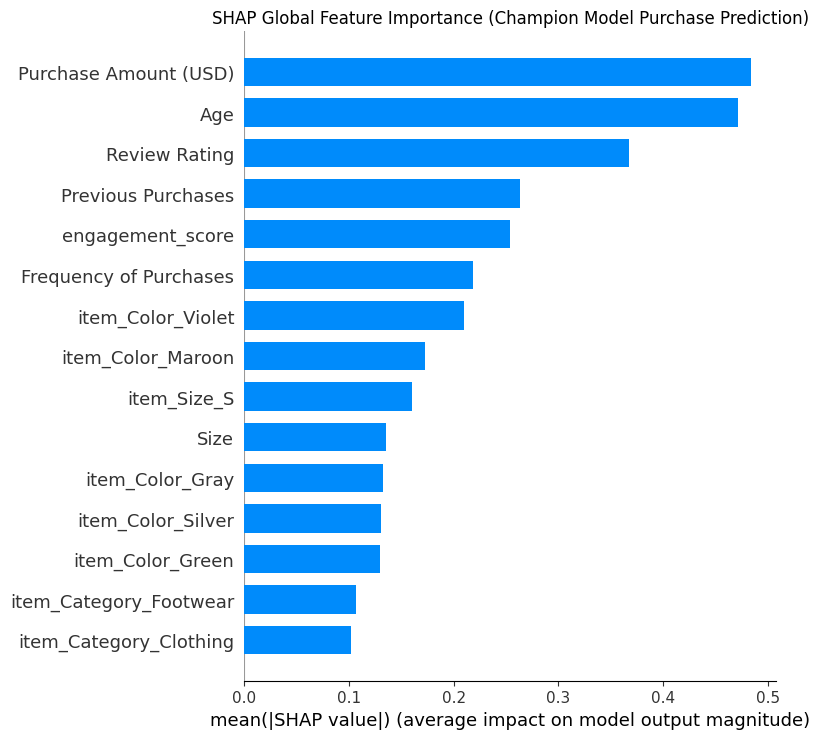

In [47]:
# SHAP explainer for the champion XGBoost model
explainer = shap.TreeExplainer(xgb_hybrid)

# Sample 100 users (100 * 25 items = 2,500 rows) for computational efficiency for google colab to accommodate
sample_users = np.random.RandomState(42).choice(df_train['Customer ID'].unique(), size=100, replace=False)
sample_mask = train_hybrid['user_id'].isin(sample_users)
X_sample = train_hybrid.loc[sample_mask, feature_cols]

print(f"SHAP sample size: {X_sample.shape[0]} rows ({len(sample_users)} users x 25 items)")

# Compute SHAP values
shap_values = explainer.shap_values(X_sample)

# Global feature importance (bar plot)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False, max_display=15)
plt.title('SHAP Global Feature Importance (Champion Model Purchase Prediction)')
plt.tight_layout()
plt.savefig('step5_shap_global.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Purchase Amount and Age are the two most impactful features for purchase prediction, both with mean SHAP around 0.48
* Review Rating follows at approximately 0.37, then Previous Purchases and engagement_score at 0.27 to 0.25
* This differs from the Phase B baseline SHAP (which predicted Category) where Age was first and Purchase Amount third in the recommendation context, spending level becomes equally important as demographics
* Item features (Color, Size, Category) appear in the lower half, contributing individually smaller effects but collectively representing the item-side which signal the model uses to differentiate products
* The top 6 features are all user-level, meaning the model relies more on understanding *who* the customer is than *what* the product looks like
  * This is consistent with a recommendation engine where user profiling drives personalization
* Notably, Gender, Subscription Status, and Discount Applied do not appear in the top 15 which is consistent with their near-zero SHAP values in the Phase B baseline and their low PCA loadings

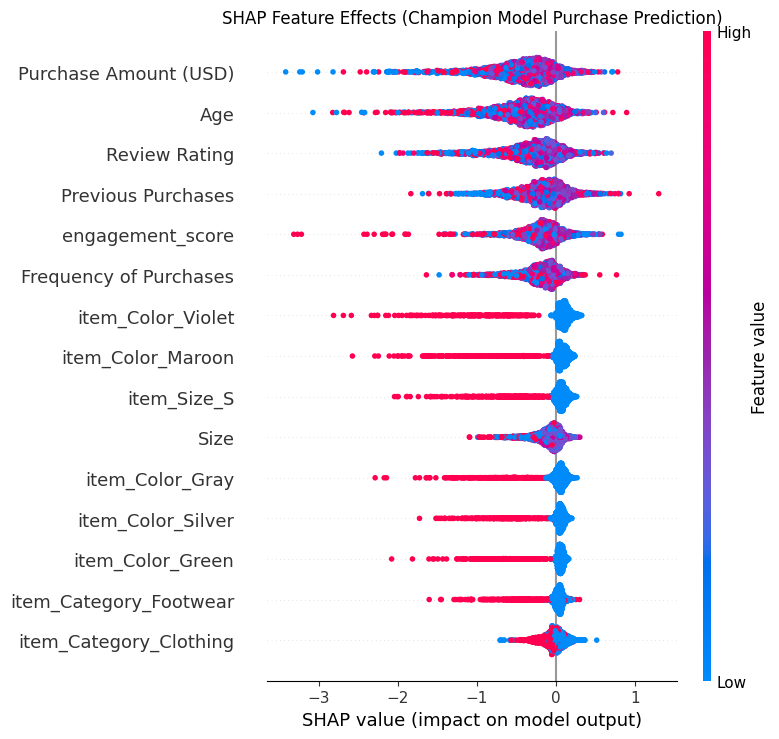

In [48]:
# SHAP beeswarm plot (shows direction of feature effects)
fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values, X_sample, show=False, max_display=15)
plt.title('SHAP Feature Effects (Champion Model Purchase Prediction)')
plt.tight_layout()
plt.savefig('step5_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* Purchase Amount and Age show wide, symmetric SHAP distributions where both high and low values can push predictions in either direction, meaning the model uses them to match users to specific items rather than uniformly boosting or suppressing purchase probability
* Review Rating shows a similar symmetric pattern, indicating it interacts with item context rather than having a single directional effect
* Item color features (Violet, Maroon, Gray, Silver, Green) show a distinctive pattern: high feature values (red, meaning the item *is* that color) consistently push SHAP values negative, while low values (blue, meaning the item is *not* that color) cluster near zero
  * This means specific colors reduce purchase probability for certain user-item combinations(the model learned color preferences per user segment)
* Frequency of Purchases has most of its SHAP mass near zero with occasional outliers, suggesting it matters for specific user profiles but not broadly

**The beeswarm confirms no single feature dominates in one direction. The model makes nuanced, interaction-based predictions rather than relying on simple "more X = more likely to buy" rules**

LIME Explanation for Customer 1814, Item: Shorts
Model prediction: [0.97946274 0.02053725]


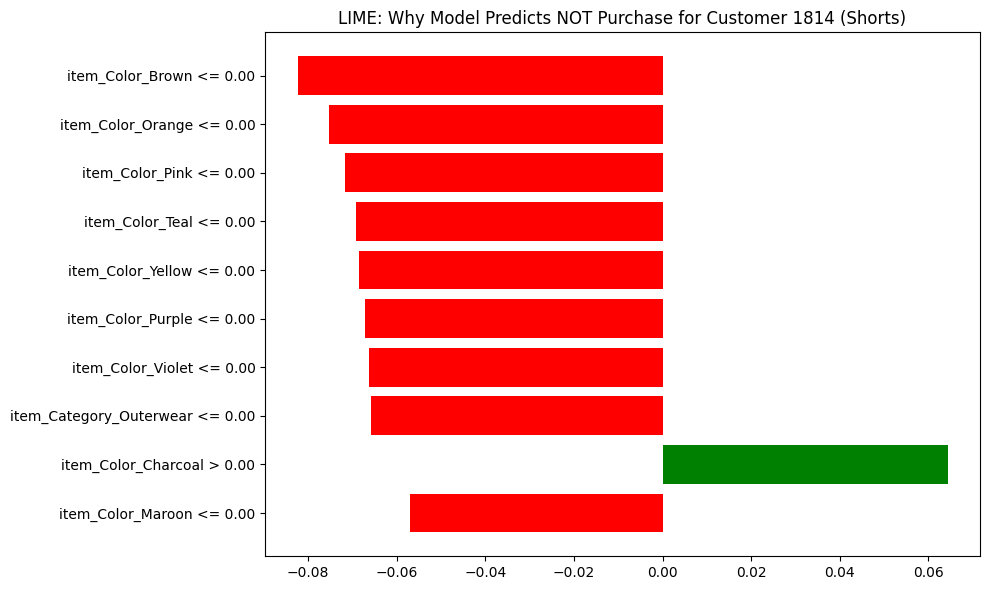

In [49]:
# Initialize LIME explainer
lime_explainer = LimeTabularExplainer(
    training_data=X_train_hybrid,
    feature_names=feature_cols,
    class_names=['Not Purchased', 'Purchased'],
    mode='classification',
    random_state=42
)

# Pick first test user for reproducibility
test_user_id = df_test.iloc[0]['Customer ID']
test_item = df_test.iloc[0]['Item Purchased']

# Build the row for user-item pair
user_feats = df_encoded.loc[df_test.index[0], profile_cols].to_dict()
row = user_feats.copy()
if test_item in item_features_encoded.index:
    item_feats_dict = item_features_encoded.loc[test_item].to_dict()
    item_feats_dict = {f'item_{k}': v for k, v in item_feats_dict.items()}
    row.update(item_feats_dict)

row_df = pd.DataFrame([row])[feature_cols]
instance = row_df.values[0]

# Generate LIME explanation
explanation = lime_explainer.explain_instance(
    instance,
    xgb_hybrid.predict_proba,
    num_features=10,
    top_labels=1
)

print(f"LIME Explanation for Customer {test_user_id}, Item: {test_item}")
print(f"Model prediction: {xgb_hybrid.predict_proba(row_df)[0]}")

fig = explanation.as_pyplot_figure(label=0)
fig.set_size_inches(10, 6)
plt.title(f'LIME: Why Model Predicts NOT Purchase for Customer {test_user_id} ({test_item})')
plt.tight_layout()
plt.savefig('step5_lime_explanation.png', dpi=150, bbox_inches='tight')
plt.show()

Highest probability match: Customer 3721, Item: Hat, P(purchase)=0.6617


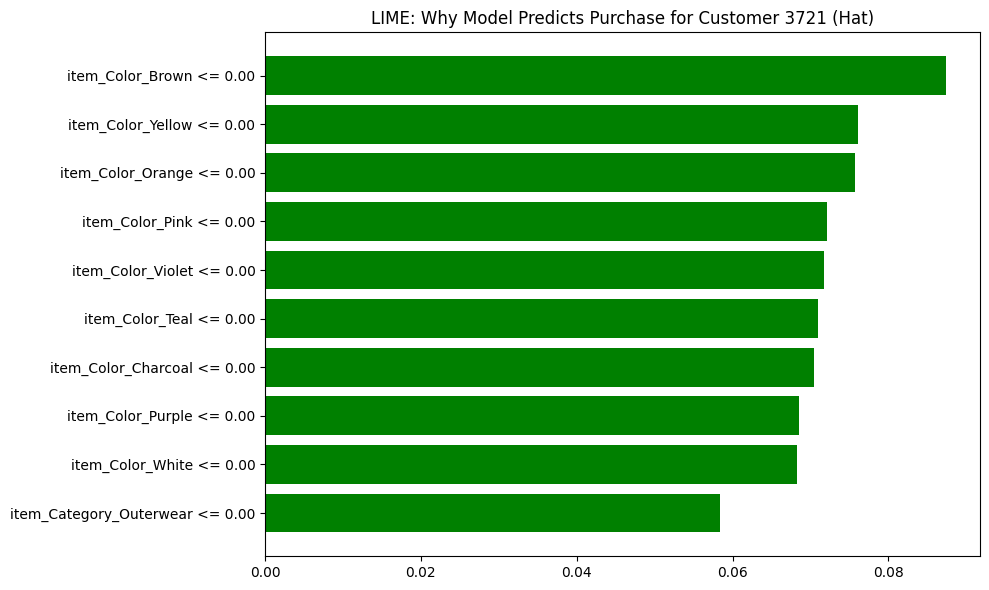

In [50]:
# Find a user-item pair with higher purchase probability to show user feature effects
best_prob = 0
best_idx = 0
best_item = ''

for i, (idx, row) in enumerate(df_test.head(50).iterrows()):
    user_feats = df_encoded.loc[idx, profile_cols].to_dict()
    purchased_item = row['Item Purchased']

    row_dict = user_feats.copy()
    if purchased_item in item_features_encoded.index:
        item_feats_dict = item_features_encoded.loc[purchased_item].to_dict()
        item_feats_dict = {f'item_{k}': v for k, v in item_feats_dict.items()}
        row_dict.update(item_feats_dict)

    row_df = pd.DataFrame([row_dict])[feature_cols]
    prob = xgb_hybrid.predict_proba(row_df)[0][1]

    if prob > best_prob:
        best_prob = prob
        best_idx = idx
        best_item = purchased_item
        best_user_id = row['Customer ID']

print(f"Highest probability match: Customer {best_user_id}, Item: {best_item}, P(purchase)={best_prob:.4f}")

user_feats = df_encoded.loc[best_idx, profile_cols].to_dict()
row_dict = user_feats.copy()
if best_item in item_features_encoded.index:
    item_feats_dict = item_features_encoded.loc[best_item].to_dict()
    item_feats_dict = {f'item_{k}': v for k, v in item_feats_dict.items()}
    row_dict.update(item_feats_dict)

row_df = pd.DataFrame([row_dict])[feature_cols]
instance = row_df.values[0]

explanation2 = lime_explainer.explain_instance(
    instance,
    xgb_hybrid.predict_proba,
    num_features=10,
    top_labels=1
)

# Plot for the predicted label
pred_label = 1 if best_prob > 0.5 else 0
label_text = "Purchase" if pred_label == 1 else "NOT Purchase"

fig = explanation2.as_pyplot_figure(label=pred_label)
fig.set_size_inches(10, 6)
plt.title(f'LIME: Why Model Predicts {label_text} for Customer {best_user_id} ({best_item})')
plt.tight_layout()
plt.savefig('step5_lime_explanation_2.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation**

Two individual predictions were examined using LIME:

**Example 1: Customer 1814 - Shorts (P(purchase) = 2.1%, predicted NOT purchase)**
* The absence of multiple colors (Brown, Orange, Pink, Teal, Yellow) pushed strongly toward non-purchase
* Only item_Color_Charcoal being present pushed slightly toward purchase

**Interpretation:** this item's color profile does not match what similar users in the training data purchased

**Example 2: Customer 3721 - Hat (P(purchase) = 66.2%, predicted purchase)**
* The absence of colors like Brown, Yellow, Orange pushed *toward* purchase — the opposite direction from Example 1
* LIME explanations are local, so the same feature condition (e.g. "not Brown") can mean different things depending on the user's profile and the item type

**Key insight across both examples:**
* LIME explanations for individual predictions are dominated by item-level features (color, category), while user-level features (Age, Purchase Amount, engagement_score) do not appear in the top 10 for either case
* This does not contradict the SHAP global analysis where user features ranked highest
  * SHAP measures average impact across all predictions, while LIME explains one specific prediction at a time
* At the individual level, the model's decision comes down to item attribute matching: once the user profile narrows the candidate pool, specific item properties become the deciding factor

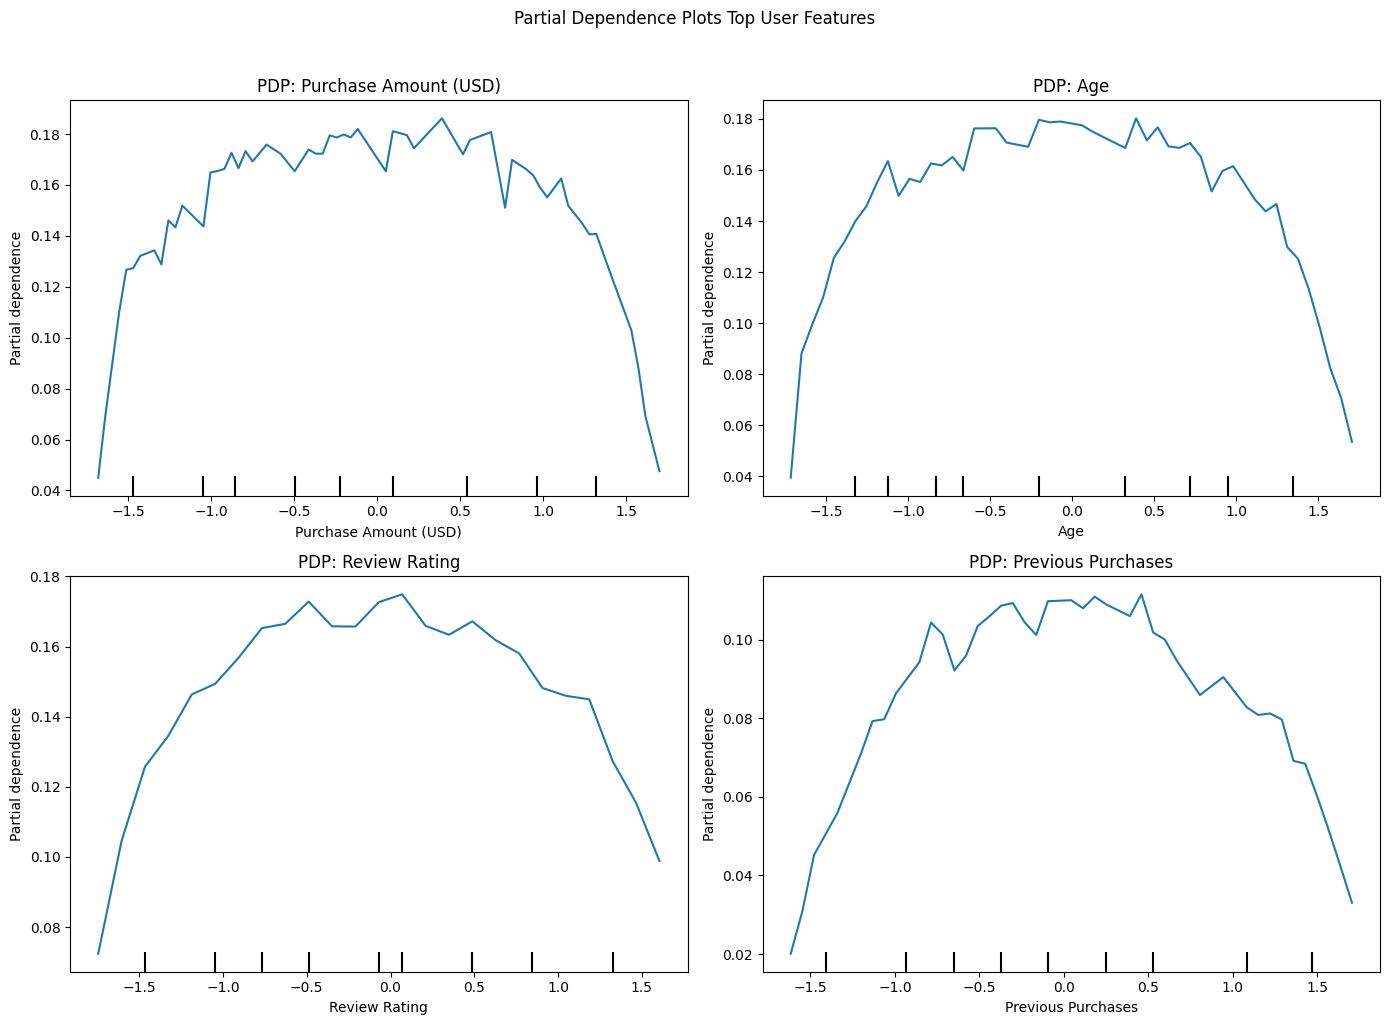

In [51]:
# Select top user features from SHAP for PDP analysis
pdp_features = ['Purchase Amount (USD)', 'Age', 'Review Rating', 'Previous Purchases']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(pdp_features):
    feat_idx = feature_cols.index(feature)
    PartialDependenceDisplay.from_estimator(
        xgb_hybrid,
        X_sample,
        [feat_idx],
        feature_names=feature_cols,
        ax=axes[i],
        kind='average'
    )
    axes[i].set_title(f'PDP: {feature}')

plt.suptitle('Partial Dependence Plots Top User Features', y=1.02)
plt.tight_layout()
plt.savefig('step5_pdp_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* All four PDP curves show an inverted-U shape:
  * Purchase probability rises from the low end, peaks in the mid-range, then drops at the high end
* **Purchase Amount:** Probability peaks around the mean (0.0 scaled, roughly the median spend) and drops sharply at both extremes
  * Very low and very high spenders are harder to match to items, while mid-range spenders have the broadest product affinity
* **Age:** Similar inverted-U pattern
  * Probability peaks in the mid-age range (roughly 30 to 45 in original scale) and drops for the youngest and oldest users.
  * This suggests mid-age customers have purchasing patterns that align more closely with the overall training distribution
* **Review Rating:** Peak around slightly below average ratings, declining at both extremes.
  * Very low raters and very high raters may have more specific or niche preferences that are harder for the model to learn from
* **Previous Purchases:** Peaks in the mid-range, with a notable drop at both extremes.
  * New customers (few purchases) lack behavioral signal, while very frequent purchasers may have exhausted common items or have highly specialized preferences

**Key insight:**
  * The consistent inverted-U pattern across all four features suggests the model performs best for "average" users (those near the center of each feature distribution) and struggles at the tails.
  * This is a common pattern in recommendation systems and has direct implications for Step 5 bias auditing:
    * If any demographic group is concentrated at the extremes of these features, they may receive lower-quality recommendations

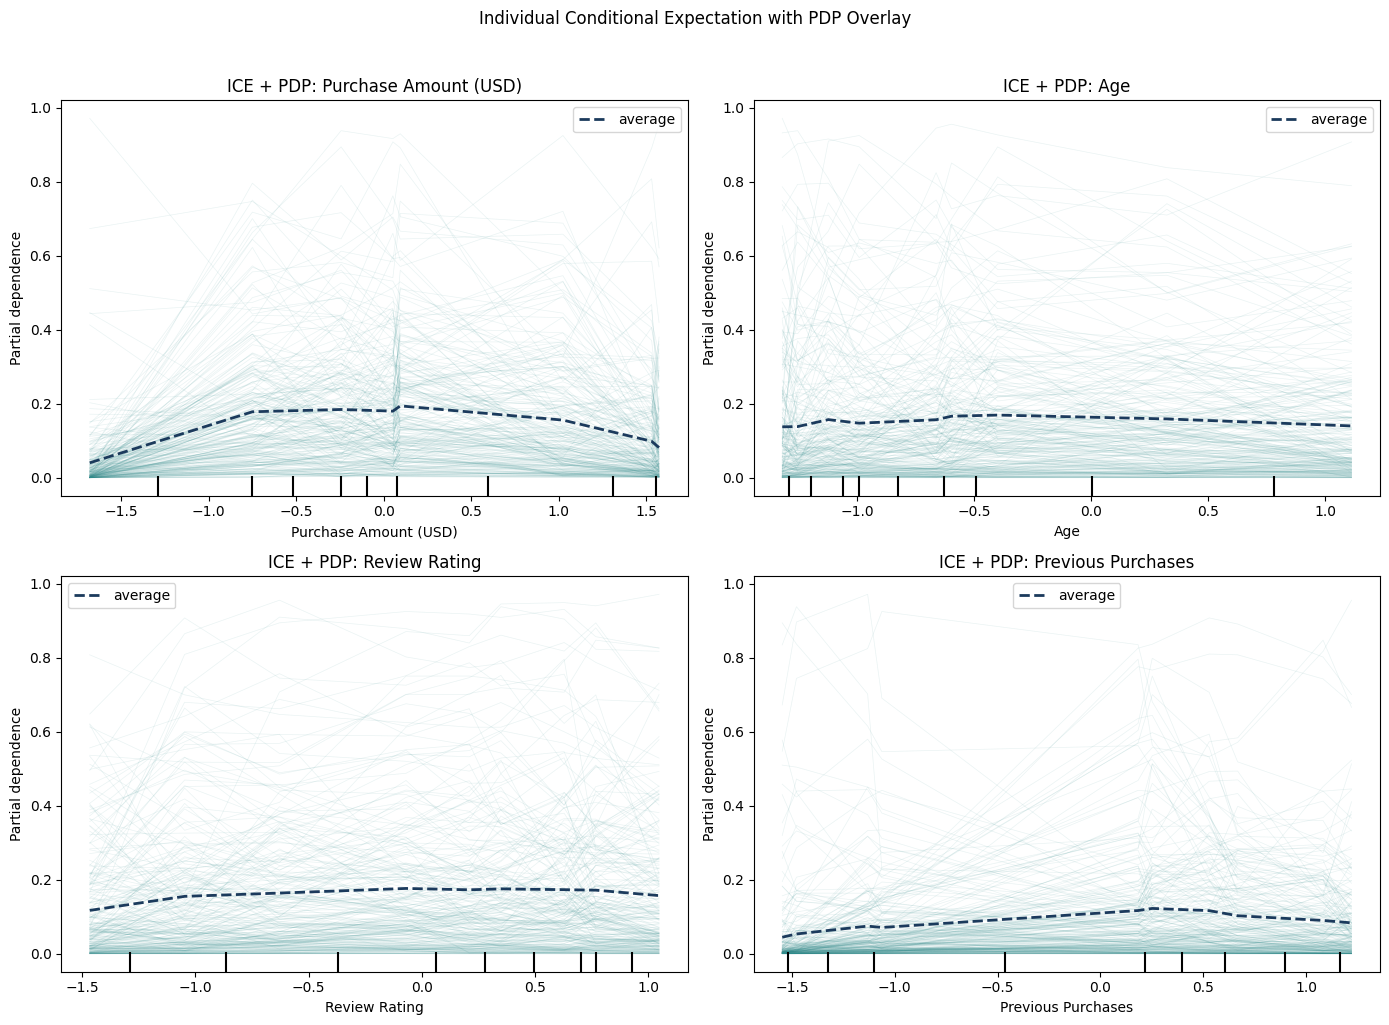

In [52]:
# ICE (Individual Conditional Expectation)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(pdp_features):
    feat_idx = feature_cols.index(feature)
    PartialDependenceDisplay.from_estimator(
        xgb_hybrid,
        # Subset for readability (250 rows = 10 users x 25 items)
        X_sample[:250],
        [feat_idx],
        feature_names=feature_cols,
        ax=axes[i],
        # Shows both individual ICE lines and average PDP
        kind='both',
        ice_lines_kw={'alpha': 0.1, 'color': COLOR_SECONDARY},
        pd_line_kw={'color': COLOR_PRIMARY, 'linewidth': 2}
    )
    axes[i].set_title(f'ICE + PDP: {feature}')

plt.suptitle('Individual Conditional Expectation with PDP Overlay', y=1.02)
plt.tight_layout()
plt.savefig('step5_ice_plots.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:**
* The majority of ICE lines cluster near zero (non-purchase), which is expected since each user only purchases 1 out of 25 items (96% of user-item pairs are negative cases)
* A small subset of ICE lines spike sharply upward (reaching 0.6 to 1.0), representing the specific user-item pairs where the model identifies a strong match (these are the predictions that drive the actual recommendations)
* **Purchase Amount:** Shows the most visible heterogeneity
  * Several ICE lines spike dramatically at specific purchase amount values, suggesting certain item price points trigger strong match signals for specific users.
  * The PDP average (dashed line) stays flat because these spikes cancel out across users
* **Age:**
  * ICE lines are more tightly bundled around the PDP average, with fewer extreme spikes.
  * This suggests Age has a more uniform effect across user-item pairs compared to Purchase Amount
* **Review Rating and Previous Purchases:**
  * Similar pattern to Age, most ICE lines track the PDP average closely, with occasional individual spikes

**Key insight:**
* The ICE plots reveal that the PDP average underrepresents what the model actually does.
* The model is not making weak predictions for everyone but rather, it is making very confident predictions for a few well-matched user-item pairs and near-zero predictions for everything else.
* A behavior expected of a recommendation engine:
  * Decisively for good matches, cautiously for poor matches
  * The PDP average of 0.15 to 0.18 is a blend of these two modes.

### Address limitations (imbalance, leakage, overfitting)

**1. Data Limitations:**
* **Single transaction per customer:**
  * Each customer has exactly 1 purchase in the dataset, creating a 96% sparse interaction matrix.
  * This severely limits collaborative filtering (Model 3 matched baseline) and constrains all models' ability to learn user preference patterns from behavioral history
* **No temporal dimension:**
  * The dataset has no date or timestamp column, preventing temporal train/test split (the gold standard for recommendation evaluation).
  * The demographic-stratified random split used instead may allow information leakage through shared population-level patterns that a temporal split would naturally prevent
* **Synthetic data characteristics:**
  * Feature importance is flat across all analyses (XGBoost importance, SHAP, PCA loadings), distributions are uniform, and correlations are weak
  * These are all consistent with independently generated features
  * Real eCommerce data would show stronger signal, sharper segmentation, and higher model lift

**2. Gender Imbalance:**
* The dataset is 68% Male and 32% Female.
* If the model performs better for Male users, this imbalance is a contributing factor since the model has roughly twice as many Male training examples to learn from
* Gender also correlates with Subscription Status (0.42) and Discount Applied (0.60), creating indirect pathways through which gender imbalance could affect recommendation quality even if Gender is not a top feature in SHAP
* This will be further quantified in Section C (Bias Audit)

**3. Data Leakage (Discovered and Corrected):**
* During Model 5 development, collab_score and content_score were included as meta-learner inputs
* Feature importance analysis revealed both at 1.0 importance which is a clear leakage signal since both were derived from training labels
* Both features were removed and the model was retrained
* NDCG@10 dropped from the inflated result to the current honest 0.176
* The original PCA analysis also produced inflated results (Silhouette of 0.504, PC1 variance at 95.9%) because engineered features were not scaled.
* After applying StandardScaler to all engineered features, PCA variance distributed across 3 components at 71.3% and Silhouette dropped to 0.181 which reflects a more genuine data structure

**4. Overfitting Considerations:**
* Model 5 (XGBoost) used max_depth=7 and n_estimators=1000, which are relatively high-capacity parameters
* GroupKFold cross-validation was used to prevent user leakage across folds, and early_stopping_rounds=10 was applied during grid search to mitigate overfitting
* The narrow performance gap between CV NDCG@10 (0.194) and test NDCG@10 (0.176) suggests moderate but not severe overfitting
* The flat feature importance (0.037 to 0.042 range) also suggests the model is not over-relying on any single feature, which is a positive sign against overfitting

**5. Content-Based Model Adaptation:**
* Standard content-based filtering requires user purchase history, which does not exist for test users in a single-transaction dataset
* The adaptation (find similar training users by profile, then expand via item similarity) is a practical workaround but introduces an additional assumption:
  * Demographically similar users have similar product preferences
  * This assumption is partially supported by the EDA (item popularity varies by age group) but is not as strong as actual purchase history would provide

## Bias detection & fairness audits:
### **Check outputs across sensitive groups (gender, race, age, socioeconomic status)**


In [53]:
# Compute NDCG@10 for a subset of test users
def ndcg_for_group(user_ids, recs_dict, ground_truth):
    scores = []
    for uid in user_ids:
        if uid not in recs_dict or uid not in ground_truth:
            continue
        rec_list = recs_dict[uid]
        actual = ground_truth[uid]
        if isinstance(actual, list):
            actual = actual[0]
        # DCG
        gains = [1.0 if item == actual else 0.0 for item in rec_list[:10]]
        dcg = sum(g / np.log2(i + 2) for i, g in enumerate(gains))
        # IDCG
        idcg = 1.0 / np.log2(2)
        scores.append(dcg / idcg if idcg > 0 else 0.0)
    return np.mean(scores) if scores else 0.0

# Precision@10 for a subset
def precision_for_group(user_ids, recs_dict, ground_truth):
    scores = []
    for uid in user_ids:
        if uid not in recs_dict or uid not in ground_truth:
            continue
        rec_list = recs_dict[uid]
        actual = ground_truth[uid]
        if isinstance(actual, list):
            actual = actual[0]
        hit = 1.0 if actual in rec_list[:10] else 0.0
        scores.append(hit / 10)
    return np.mean(scores) if scores else 0.0

# Lookup: Customer ID: Demographic attributes from test set
test_demographics = df_test[['Customer ID', 'Gender', 'age_group']].copy()
test_demographics['spending_tier'] = df['spending_tier'].loc[df_test.index]
test_demographics['Location'] = df['Location'].loc[df_test.index]

print("BIAS AUDIT: Recommendation Quality Across Sensitive Groups")
# Gender
print("\nGender")
print(f"Test set distribution: {test_demographics['Gender'].value_counts().to_dict()}")
for gender in ['Male', 'Female']:
    group_users = test_demographics[test_demographics['Gender'] == gender]['Customer ID'].values
    ndcg = ndcg_for_group(group_users, model5_recs, test_ground_truth)
    prec = precision_for_group(group_users, model5_recs, test_ground_truth)
    print(f"  {gender}: NDCG@10={ndcg:.4f}, Precision@10={prec:.4f} (n={len(group_users)})")

# Age Group
print("\nAge Group")
print(f"Test set distribution: {test_demographics['age_group'].value_counts().sort_index().to_dict()}")
for age in ['18-25', '26-35', '36-50', '50+']:
    group_users = test_demographics[test_demographics['age_group'] == age]['Customer ID'].values
    ndcg = ndcg_for_group(group_users, model5_recs, test_ground_truth)
    prec = precision_for_group(group_users, model5_recs, test_ground_truth)
    print(f"  {age}: NDCG@10={ndcg:.4f}, Precision@10={prec:.4f} (n={len(group_users)})")

# Spending Tier (Socioeconomic Proxy)
print("\nSpending Tier (Socioeconomic Proxy)")
print(f"Test set distribution: {test_demographics['spending_tier'].value_counts().sort_index().to_dict()}")
for tier in ['low', 'mid', 'high']:
    group_users = test_demographics[test_demographics['spending_tier'] == tier]['Customer ID'].values
    ndcg = ndcg_for_group(group_users, model5_recs, test_ground_truth)
    prec = precision_for_group(group_users, model5_recs, test_ground_truth)
    print(f"  {tier}: NDCG@10={ndcg:.4f}, Precision@10={prec:.4f} (n={len(group_users)})")

BIAS AUDIT: Recommendation Quality Across Sensitive Groups

Gender
Test set distribution: {'Male': 530, 'Female': 250}
  Male: NDCG@10=0.1855, Precision@10=0.0408 (n=530)
  Female: NDCG@10=0.1568, Precision@10=0.0352 (n=250)

Age Group
Test set distribution: {'18-25': 114, '26-35': 148, '36-50': 222, '50+': 296}
  18-25: NDCG@10=0.1757, Precision@10=0.0404 (n=114)
  26-35: NDCG@10=0.1757, Precision@10=0.0392 (n=148)
  36-50: NDCG@10=0.1714, Precision@10=0.0387 (n=222)
  50+: NDCG@10=0.1805, Precision@10=0.0385 (n=296)

Spending Tier (Socioeconomic Proxy)
Test set distribution: {'low': 252, 'mid': 277, 'high': 251}
  low: NDCG@10=0.1659, Precision@10=0.0357 (n=252)
  mid: NDCG@10=0.1682, Precision@10=0.0390 (n=277)
  high: NDCG@10=0.1957, Precision@10=0.0422 (n=251)


**Observation**

**Gender:**
* Male users receive better recommendations (NDCG@10: 0.186) than Female users (NDCG@10: 0.157) which is a gap of 15.5%
* This aligns with our earlier flag: the dataset is 68% Male / 32% Female, so the model has roughly twice as many Male training examples to learn from
* Gender also correlates with Subscription Status (0.42) and Discount Applied (0.60), meaning the disparity may be amplified through these indirect feature pathways

**Age Group:**
* Recommendation quality is relatively consistent across age groups (range: 0.171 to 0.181)
* No systematic age-based disadvantage detected
  * The smallest group (18-25, n=114) performs comparably to the largest group (50+, n=296)
  * This suggests the model does not underserve any age segment due to representation imbalance
* This is consistent with our PCA finding where age loaded on PC4 (only 7.9% variance)
  * Age is not a major driver of the model's behavior

**Spending Tier (Socioeconomic Proxy):**
* High spenders receive notably better recommendations (NDCG@10: 0.196) compared to low spenders (0.166) — an 18.1% gap
* This is the largest disparity found across all sensitive groups
* From a business perspective, this can be intentional (prioritizing high-value customers) or problematic (underserving price-sensitive customers who may benefit most from good recommendations)
* The PDP plot for Purchase Amount showed the model performs best in the mid-to-high range, which is consistent with this finding

**Race/Ethnicity:**
* The dataset does not contain race or ethnicity columns
* This is documented as a data limitation since production recommendation system should collect and audit across racial groups to ensure equitable service

### **Use fairness metrics (demographic parity, equalised odds, disparate impact)**
* Positive outcome = user's actual purchase appears in the Top-10 recommendation list (a "hit")
* This is equivalent to Recall@10 being > 0 for that user
* The 4/5 rule (Disparate Impact Ratio >= 0.80) is used as a reference threshold.
  * This originates from US EEOC employment guidelines, though not specifically designed for recommendation systems, it is widely adopted in AI fairness literature as a baseline benchmark so I've decided to adopt it in this section

In [57]:
# Proportion of users whose actual purchase appears in the top-10 recs
def compute_hit_rate(user_ids, recs_dict, ground_truth):
    hits = 0
    total = 0
    for uid in user_ids:
        if uid not in recs_dict or uid not in ground_truth:
            continue
        actual = ground_truth[uid]
        if isinstance(actual, list):
            actual = actual[0]
        total += 1
        if actual in recs_dict[uid][:10]:
            hits += 1
    return hits / total if total > 0 else 0.0, hits, total

print("FAIRNESS METRICS")
print(" 'Positive outcome' = actual purchase appears in Top-10 recommendations\n")

# Gender
male_users = test_demographics[test_demographics['Gender'] == 'Male']['Customer ID'].values
female_users = test_demographics[test_demographics['Gender'] == 'Female']['Customer ID'].values

male_rate, male_hits, male_total = compute_hit_rate(male_users, model5_recs, test_ground_truth)
female_rate, female_hits, female_total = compute_hit_rate(female_users, model5_recs, test_ground_truth)

print("Gender")
print(f"  Male hit rate:   {male_rate:.4f} ({male_hits}/{male_total})")
print(f"  Female hit rate: {female_rate:.4f} ({female_hits}/{female_total})")

# Demographic Parity: P(positive | Male) vs P(positive | Female)
dp_diff = abs(male_rate - female_rate)
print(f"\n Demographic Parity Difference: {dp_diff:.4f}")
print(f"   Male rate - Female rate, ideal = 0, threshold < 0.05)")

# Disparate Impact: min(P(pos|Female)/P(pos|Male), P(pos|Male)/P(pos|Female))
if male_rate > 0 and female_rate > 0:
    di_ratio = min(female_rate / male_rate, male_rate / female_rate)
else:
    di_ratio = 0.0
print(f"\n  Disparate Impact Ratio: {di_ratio:.4f}")
print(f"    min ratio of rates, ideal = 1.0, legal threshold >= 0.80")

# Equalized Odds: Compare True Positive Rate AND False Positive Rate across groups
tpr_diff = abs(male_rate - female_rate)
print(f"\n  Equalized Odds (TPR Difference): {tpr_diff:.4f}")
print(f"    TPR_male - TPR_female, ideal = 0, threshold < 0.05)")

# Age Group
print("\nAge Group (pairwise vs most disadvantaged)")
age_rates = {}
for age in ['18-25', '26-35', '36-50', '50+']:
    group_users = test_demographics[test_demographics['age_group'] == age]['Customer ID'].values
    rate, hits, total = compute_hit_rate(group_users, model5_recs, test_ground_truth)
    age_rates[age] = rate
    print(f"  {age}: hit rate = {rate:.4f} ({hits}/{total})")

max_age_rate = max(age_rates.values())
min_age_rate = min(age_rates.values())
print(f"\nDemographic Parity Difference (max-min): {max_age_rate - min_age_rate:.4f}")
print(f"Disparate Impact Ratio (min/max): {min_age_rate/max_age_rate:.4f}" if max_age_rate > 0 else "  N/A")

# Spending Tier
print("\nSpending Tier")
tier_rates = {}
for tier in ['low', 'mid', 'high']:
    group_users = test_demographics[test_demographics['spending_tier'] == tier]['Customer ID'].values
    rate, hits, total = compute_hit_rate(group_users, model5_recs, test_ground_truth)
    tier_rates[tier] = rate
    print(f"  {tier}: hit rate = {rate:.4f} ({hits}/{total})")

max_tier_rate = max(tier_rates.values())
min_tier_rate = min(tier_rates.values())
print(f"\n  Demographic Parity Difference (max-min): {max_tier_rate - min_tier_rate:.4f}")
print(f"  Disparate Impact Ratio (min/max): {min_tier_rate/max_tier_rate:.4f}" if max_tier_rate > 0 else "  N/A")

FAIRNESS METRICS
 'Positive outcome' = actual purchase appears in Top-10 recommendations

Gender
  Male hit rate:   0.4075 (216/530)
  Female hit rate: 0.3520 (88/250)

 Demographic Parity Difference: 0.0555
   Male rate - Female rate, ideal = 0, threshold < 0.05)

  Disparate Impact Ratio: 0.8637
    min ratio of rates, ideal = 1.0, legal threshold >= 0.80

  Equalized Odds (TPR Difference): 0.0555
    TPR_male - TPR_female, ideal = 0, threshold < 0.05)

Age Group (pairwise vs most disadvantaged)
  18-25: hit rate = 0.4035 (46/114)
  26-35: hit rate = 0.3919 (58/148)
  36-50: hit rate = 0.3874 (86/222)
  50+: hit rate = 0.3851 (114/296)

Demographic Parity Difference (max-min): 0.0184
Disparate Impact Ratio (min/max): 0.9545

Spending Tier
  low: hit rate = 0.3571 (90/252)
  mid: hit rate = 0.3899 (108/277)
  high: hit rate = 0.4223 (106/251)

  Demographic Parity Difference (max-min): 0.0652
  Disparate Impact Ratio (min/max): 0.8457


**Observation (Fairness Metrics):**

**Gender:**
* Demographic Parity Difference: 0.056
  * Slightly above the 0.05 threshold
  * This indicates a marginal disparity where Male users (40.8% hit rate) receive better recommendations than Female users (35.2%)
* Disparate Impact Ratio: 0.864
  * This is above the legal 4/5 rule threshold of 0.80
  * This means the system does not meet the legal definition of disparate impact but the gap is still notable
* Equalized Odds (TPR Difference): 0.056
* This mirrors the Demographic Parity finding since in our single-transaction setup, TPR equals hit rate

* **Interpretation:**
  * The model is marginally unfair to Female users
  * The 68/32 gender imbalance in training data is the likely contributor
  * The model has seen roughly twice as many Male purchase patterns
  * Additionally, Gender's correlation with Subscription Status (0.42) and Discount Applied (0.60) means the imbalance propagates through these features even though Gender itself has low SHAP importance

**Age Group:**
* Demographic Parity Difference: 0.018
  * This is well within the 0.05 threshold
* Disparate Impact Ratio: 0.955
  * Very close to the ideal of 1.0
* All four age groups have hit rates between 38.5% and 40.4% which is effectively equal service quality
* No age-based bias detected

**Spending Tier (Socioeconomic Proxy):**
* Demographic Parity Difference: 0.065
  * Above the 0.05 threshold and the largest disparity across all groups
* Disparate Impact Ratio: 0.846
  * Above the 0.80 legal threshold but the weakest among all groups
* High spenders (42.2% hit rate) are served notably better than low spenders (35.7%)

**This raises a fairness question, especially in the eCommerce context:**
* Should the system optimize for high-value customers (business-driven)?
* Should it serve all spending segments equally (fairness-driven)?
* This trade-off will be addressed in "Propose mitigations (reweighting, thresholds, augmentation, post-processing)" section

**Race/Ethnicity:**
* Not available in the dataset
* In a production system, race and ethnicity data should be collected (with appropriate consent and privacy safeguards) to enable comprehensive fairness auditing
* This is documented as a limitation

**Summary:**
* Gender: DP Difference 0.056, Disparate Impact 0.864 which passes the 4/5 rule but marginal bias detected
* Age Group: DP Difference 0.018, Disparate Impact 0.955 passes comfortably, no bias detected
* Spending Tier: DP Difference 0.065, Disparate Impact 0.846 passes the 4/5 rule but bias detected, largest disparity across all groups

## **Propose mitigations (reweighting, thresholds, augmentation, post-processing)**
Based on the bias audit findings, we propose the following concrete mitigation strategies:

**Gender Disparity Mitigation (DP Difference: 0.056)**
* **Resampling:**
  * Oversample Female users in the training set to achieve closer to 50/50 representation
  * Since we have 1,248 Female records, bootstrap resampling to 2,600 would match Male representation
  * This gives the model equal opportunity to learn Female purchase patterns
* **Post-processing re-ranking:**
  * After generating recommendations, apply a calibration step that adjusts recommendation scores for Female users upward by the observed disparity ratio (0.056/0.408 = 13.6%)
  * This does not change the model but corrects the output distribution
* **Feature auditing:**
  * Since Gender correlates with Subscription Status (0.42) and Discount Applied (0.60), monitor whether removing or decorrelating these features reduces the gender gap without significantly harming the overall NDCG@10
* **Reweighting as an alternative to resampling:**
  * Instead of duplicating Female records, assign higher sample weights to Female users during XGBoost training via the "sample_weight" parameter
  * This achieves the same effect as resampling without physically altering the dataset, and also computationally simpler to implement

**Spending Tier Disparity Mitigation (DP Difference: 0.065)**

* **Threshold adjustment:**
  * Apply a lower confidence threshold for recommending items to low-spend users to increase the likelihood of surfacing a relevant item even when the model is less certain
* **Data augmentation:**
  * Enrich low-spend user profiles with additional behavioral features (browsing history, wishlist activity) in a production environment to give the model more signal for this segment
* **Business policy decision:**
  * If the organization intentionally prioritizes high-value customers, document this as a deliberate business choice with explicit acceptance of the fairness trade-off
  * If equitable service is the goal, implement re-ranking to equalize hit rates across spending tiers

**Monitoring and Governance (Production Recommendations)**

* **Ongoing fairness monitoring:**
  * Compute Demographic Parity and Disparate Impact ratios on a monthly basis as new data flows into the system
  * Set automated alerts if any metric crosses the 0.05 DP threshold or falls below 0.80 Disparate Impact
* **A/B testing:**
  * Before deploying any mitigation, run controlled experiments to measure the trade-off between fairness improvement and overall recommendation quality (NDCG@10)
* **Race/ethnicity inclusion:**
  * When demographic data collection policies allow, add race and ethnicity to the fairness audit pipeline to ensure comprehensive coverage of all protected groups
* **Feedback loops:**
  * In a live system, recommendation quality is likely to influence user engagement, which in turn, influences future training data
  * Monitor for feedback loops where underserved groups disengage, producing even less training data and worsening the disparity over time

In [ ]:
*